# 2x2-smoothed pure-space anisotropic generalized Cauchy fixed-beta spectral diagnostic

This notebook fits each hourly 2024-07-03 pure-space slice from `2x2_tco_grid_24_07.pkl` with anisotropic ClusterB2 Vecchia and a generalized Cauchy covariance.

- beta is fixed at `3.5`
- the variant estimates `log_phi1`, `log_phi2`, and `log_phi3`
- nugget is fixed at zero
- `gc_alpha=0.6` is fixed to keep the local roughness near the Matérn `smooth=0.3` target

The cluster Vecchia geometry follows the 2x2 Matérn comparison notebook: 4x4 cluster blocks, max-min ordering on cluster centroids, and conditioning on the nearest 2 previous cluster blocks.


In [1]:
import gc
import importlib
import pickle
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.special import gamma, kv

LOCAL_SRC = '/Users/joonwonlee/Documents/GEMS_TCO-1/src'
AMAREL_SRC = '/home/jl2815/tco'
SRC = AMAREL_SRC if Path(AMAREL_SRC).exists() else LOCAL_SRC
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed
import GEMS_TCO.kernels_space_base_engine_052126 as kernels_space_base_engine_052126
import GEMS_TCO.kernels_space_aniso_cauchy_cluster_060326 as kernels_space_aniso_cauchy_cluster_060326

importlib.reload(kernels_space_base_engine_052126)
importlib.reload(kernels_space_aniso_cauchy_cluster_060326)

from GEMS_TCO.kernels_space_aniso_cauchy_cluster_060326 import (
    ClusterSpaceAnisoCauchyFixedBetaNoNuggetTrendVecchiaFit,
    cauchy_phi_init_from_natural,
)

DEVICE = torch.device('cpu')
DTYPE = torch.float64
ROUND_DECIMALS = 4

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 220)
print('SRC:', SRC)
print('device:', DEVICE)


SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
device: cpu


In [2]:
# Experiment config
YEAR = '2024'
MONTH = 7
DAY_IDX = 2                 # 0-based: 2 -> 2024-07-03
HOUR_IDX_LIST = list(range(8))
LAT_RANGE = [-3, 2]
LON_RANGE = [121, 131]
DATA_FILENAME = '2x2_tco_grid_24_07.pkl'

GC_ALPHA = 0.6
SMOOTH = GC_ALPHA           # Kept for compatibility with shared plotting labels.
GC_BETA_GRID = [3.5]
RESOLUTION_STRIDES = [8, 4, 2, 1]
MEAN_DESIGN = 'lat'


def beta_variant_name(beta):
    return f"cauchy_beta{str(float(beta)).replace('.', 'p')}"


VARIANT_LABELS = {beta_variant_name(beta): f"beta={beta:g}" for beta in GC_BETA_GRID}

CLUSTER_SPEC = {
    'block_shape': (4, 4),
    'n_neighbor_blocks': 2,
    'target_chunk_size': 128,
    'min_target_points': 1,
}

VARIANTS = {}
for beta in GC_BETA_GRID:
    name = beta_variant_name(beta)
    VARIANTS[name] = {
        'class': ClusterSpaceAnisoCauchyFixedBetaNoNuggetTrendVecchiaFit,
        'model': f'ClusterSpaceAnisoGeneralizedCauchyBeta{beta:g}NoNugget_4x4_B2_exactloc',
        'kernel': f'cluster_space_aniso_generalized_cauchy_alpha06_beta{beta:g}_nugget0_4x4_b2_exactloc',
        'p_labels': ['phi1', 'phi2', 'phi3'],
        'gc_beta': float(beta),
        'init': cauchy_phi_init_from_natural(
            sigmasq=13.0,
            range_lat=0.25,
            range_lon=0.25,
            gc_beta=float(beta),
        ),
    }

LBFGS_LR = 1.0
LBFGS_STEPS_FULL = 8
LBFGS_EVAL = 20
LBFGS_HIST = 10
GRAD_TOL = 1e-5

RUN_FULL = True
RUN_SPECTRUM = True
RUN_PROFILE_FITS = False

PURE_SPACE_DIR = Path('/Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space')
OUT_DIR = PURE_SPACE_DIR / 'log'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PREFIX = '2x2_real_pure_space_spectral_aniso_cauchy_alpha06_beta3p5_nugget0_clusterb2_121131_060326'

print('day:', f'{YEAR}{MONTH:02d}{DAY_IDX + 1:02d}')
print('hours:', HOUR_IDX_LIST)
print('strides:', RESOLUTION_STRIDES)
print('data filename:', DATA_FILENAME)
print('gc_alpha:', GC_ALPHA)
print('gc_beta_grid:', GC_BETA_GRID)
print('variants:', list(VARIANTS))
print('initial phi params:', {k: v['init'] for k, v in VARIANTS.items()})


day: 20240703
hours: [0, 1, 2, 3, 4, 5, 6, 7]
strides: [8, 4, 2, 1]
data filename: 2x2_tco_grid_24_07.pkl
gc_alpha: 0.6
gc_beta_grid: [3.5]
variants: ['cauchy_beta3p5']
initial phi params: {'cauchy_beta3p5': {'phi1': 52.0, 'phi2': 4.0, 'phi3': 1.0, 'gc_beta': 3.5}}


In [3]:
def phys_to_log(init, p_labels):
    return [np.log(init[p]) for p in p_labels]


def backmap(raw, p_labels, variant):
    est_raw = {p: float(np.exp(raw[i])) for i, p in enumerate(p_labels)}
    if {'phi1', 'phi2', 'phi3'}.issubset(est_raw):
        phi1 = est_raw['phi1']
        phi2 = est_raw['phi2']
        phi3 = est_raw['phi3']
        range_lon = 1.0 / phi2
        range_lat = 1.0 / (phi2 * np.sqrt(phi3))
        sigmasq = phi1 / phi2
        gc_beta = float(est_raw.get('gc_beta', VARIANTS[variant].get('gc_beta', np.nan)))
        return {
            **est_raw,
            'sigmasq': float(sigmasq),
            'range_lat': float(range_lat),
            'range_lon': float(range_lon),
            'range': float(range_lon),
            'nugget': 0.0,
            'gc_alpha': float(GC_ALPHA),
            'gc_beta': gc_beta,
        }
    est = {p: float(np.exp(raw[i])) for i, p in enumerate(p_labels)}
    if 'nugget' not in est:
        est['nugget'] = 0.0
    return est


def make_full_params(variant):
    spec = VARIANTS[variant]
    return [torch.tensor([v], device=DEVICE, dtype=DTYPE, requires_grad=True) for v in phys_to_log(spec['init'], spec['p_labels'])]


def count_valid(input_map):
    return int(sum(((~torch.isnan(v[:, 2])) & (~torch.isnan(v[:, 0])) & (~torch.isnan(v[:, 1]))).sum().item() for v in input_map.values()))


def space_diag(model):
    if hasattr(model, 'cluster_summary'):
        return dict(model.cluster_summary())

    groups = getattr(model, 'Batched_Groups', []) or []
    if not groups:
        return {'n_batches': 0, 'n_tails': 0, 'mean_m': 0.0, 'max_m': 0, 'largest_batch_n': 0}
    ns = np.asarray([int(g['target_idx'].shape[0]) for g in groups], dtype=np.int64)
    ms = np.asarray([int(g['max_m']) for g in groups], dtype=np.int64)
    return {
        'n_batches': int(len(groups)),
        'n_tails': int(ns.sum()),
        'mean_m': float(ms.mean()),
        'max_m': int(ms.max()),
        'largest_batch_n': int(ns.max()),
    }


def round_df(df, digits=ROUND_DECIMALS):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(digits)
    return out


def empty_cache():
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


def resolution_label(stride):
    return f'x{int(stride)}'


In [4]:
loader = load_data_dynamic_processed(config.mac_data_load_path)
input_path = Path(config.mac_data_load_path) / f'pickle_{YEAR}' / DATA_FILENAME
print('input:', input_path)
if not input_path.exists():
    raise FileNotFoundError(f'2x2 input pickle not found: {input_path}')

with input_path.open('rb') as f:
    raw_map = pickle.load(f)

# Match load_tco_grid_dicts key convention used by the original notebook.
df_map = {}
for key, df in raw_map.items():
    tmp = df.copy().reset_index(drop=True)
    if LAT_RANGE is not None and LON_RANGE is not None:
        mask = (
            (tmp['Latitude'] >= LAT_RANGE[0]) & (tmp['Latitude'] <= LAT_RANGE[1]) &
            (tmp['Longitude'] >= LON_RANGE[0]) & (tmp['Longitude'] <= LON_RANGE[1])
        )
        tmp = tmp.loc[mask].reset_index(drop=True)
    df_map[f'{YEAR}_{MONTH:02d}_{key}'] = tmp

ozone_vals = [
    pd.to_numeric(df['ColumnAmountO3'], errors='coerce').to_numpy(dtype=float)
    for df in df_map.values()
]
raw_monthly_mean = float(np.nanmean(np.concatenate(ozone_vals))) if ozone_vals else 0.0

month_keys = sorted(df_map.keys())
day_keys = month_keys[DAY_IDX * 8:(DAY_IDX + 1) * 8]
if len(day_keys) != 8:
    raise ValueError(f'Day {DAY_IDX} has {len(day_keys)} slices, expected 8')

first_df = df_map[day_keys[0]].reset_index(drop=True)
grid_order = (
    first_df
    .assign(_orig_idx=np.arange(len(first_df)))
    .sort_values(['Longitude', 'Latitude', '_orig_idx'], kind='mergesort')['_orig_idx']
    .to_numpy(dtype=np.int64)
)
grid_coords_full = first_df.iloc[grid_order][['Latitude', 'Longitude']].to_numpy(dtype=np.float64)

# Full-grid topology used by both fitting thins and spectral diagnostics.
_lat_key = np.round(grid_coords_full[:, 0], 10)
_lon_key = np.round(grid_coords_full[:, 1], 10)
lat_vals = np.sort(np.unique(_lat_key))
lon_vals = np.sort(np.unique(_lon_key))
lat_to_row = {float(v): i for i, v in enumerate(lat_vals)}
lon_to_col = {float(v): i for i, v in enumerate(lon_vals)}
local_to_row = np.asarray([lat_to_row[float(v)] for v in _lat_key], dtype=np.int64)
local_to_col = np.asarray([lon_to_col[float(v)] for v in _lon_key], dtype=np.int64)
N_LAT, N_LON = len(lat_vals), len(lon_vals)
LAT_STEP = float(np.median(np.diff(lat_vals))) if N_LAT > 1 else 1.0
LON_STEP = float(np.median(np.diff(lon_vals))) if N_LON > 1 else 1.0

ANALYSIS_MONTHLY_MEAN = 0.0
print('raw monthly_mean:', round(raw_monthly_mean, 4), '(not subtracted; intercept handles the level)')
print('day keys:', day_keys[0], '...', day_keys[-1])
print('full grid:', grid_coords_full.shape)
print('unique lat/lon:', N_LAT, N_LON)
print('lat/lon step:', LAT_STEP, LON_STEP)
print('first hour missing O3:', int(first_df['ColumnAmountO3'].isna().sum()))


input: /Users/joonwonlee/Documents/GEMS_DATA/pickle_2024/2x2_tco_grid_24_07.pkl
raw monthly_mean: 257.9885 (not subtracted; intercept handles the level)
day keys: 2024_07_y24m07day03_hm00:53 ... 2024_07_y24m07day03_hm07:48
full grid: (4503, 2)
unique lat/lon: 57 79
lat/lon step: 0.08800000000000002 0.12600000000000477
first hour missing O3: 0


In [5]:
def load_hour_map(hour_idx):
    key = day_keys[int(hour_idx)]
    hour_df_map = {key: df_map[key]}
    hour_map, _ = loader.load_working_data(
        hour_df_map,
        monthly_mean=ANALYSIS_MONTHLY_MEAN,
        idx_for_datamap=[0, 1],
        ord_mm=grid_order,
        dtype=DTYPE,
        keep_ori=True,
    )
    return {k: v.to(DEVICE) for k, v in hour_map.items()}, key


def thin_hour_map(hour_map, stride):
    """Thin on the 2D regular grid, not by 1D every-k flattening."""
    stride = int(stride)
    if stride <= 0:
        raise ValueError(f'stride must be positive, got {stride}')
    keep = (local_to_row % stride == 0) & (local_to_col % stride == 0)
    thin_idx = np.flatnonzero(keep).astype(np.int64)
    thin_map = {k: v[thin_idx].contiguous() for k, v in hour_map.items()}
    thin_grid = np.ascontiguousarray(grid_coords_full[thin_idx])
    return thin_map, thin_grid, thin_idx


def build_model(variant, input_map, grid_coords):
    spec = VARIANTS[variant]
    return spec['class'](
        smooth=SMOOTH,
        input_map=input_map,
        grid_coords=np.ascontiguousarray(grid_coords.astype(np.float64)),
        block_shape=CLUSTER_SPEC['block_shape'],
        n_neighbor_blocks=CLUSTER_SPEC['n_neighbor_blocks'],
        target_chunk_size=CLUSTER_SPEC['target_chunk_size'],
        min_target_points=CLUSTER_SPEC['min_target_points'],
        mean_design=MEAN_DESIGN,
        gc_alpha=GC_ALPHA,
        gc_beta=spec.get('gc_beta', 1.0),
    )


def make_base_row(variant, hour_idx, time_key, stride, n_grid, n_valid, pre_s, fit_s, loss, fit_iter, est, diag):
    spec = VARIANTS[variant]
    row = {
        'date_str': f'{YEAR}{MONTH:02d}{DAY_IDX + 1:02d}',
        'day_idx': DAY_IDX,
        'hour_idx': int(hour_idx),
        'time_key': str(time_key),
        'resolution_stride': int(stride),
        'resolution_label': resolution_label(stride),
        'variant': variant,
        'smooth': float(GC_ALPHA),
        'gc_alpha': float(est.get('gc_alpha', GC_ALPHA)),
        'mean_design': MEAN_DESIGN,
        'fit_type': 'full',
        'model': spec['model'],
        'kernel': spec['kernel'],
        'coord_mode': '2D grid thinning by stride in both lat/lon, fixed thinned grid order; 4x4 cluster max-min ordering on cluster centroids; anisotropic generalized Cauchy covariance on Source_Latitude/Source_Longitude',
        'loss': float(loss),
        'fit_iter_raw': int(fit_iter),
        'fit_steps_reported': int(fit_iter) + 1,
        'precompute_s': float(pre_s),
        'fit_s': float(fit_s),
        'total_s': float(pre_s + fit_s),
        'n_grid': int(n_grid),
        'n_valid': int(n_valid),
        'valid_fraction': float(n_valid / n_grid) if n_grid else np.nan,
        'est_sigmasq': float(est['sigmasq']),
        'est_range': float(est['range_lon']),
        'est_range_lat': float(est['range_lat']),
        'est_range_lon': float(est['range_lon']),
        'est_nugget': 0.0,
        'est_phi1': float(est['phi1']),
        'est_phi2': float(est['phi2']),
        'est_phi3': float(est['phi3']),
        'est_gc_alpha': float(est.get('gc_alpha', GC_ALPHA)),
        'est_gc_beta': float(est['gc_beta']),
        **diag,
        'cluster_block_shape': '4x4',
        'cluster_neighbor_blocks': CLUSTER_SPEC['n_neighbor_blocks'],
        'total_conditioning_nominal': int(CLUSTER_SPEC['n_neighbor_blocks'] * np.prod(CLUSTER_SPEC['block_shape'])),
    }
    return row


In [6]:
def fit_full_variant(variant, hour_idx, stride):
    hour_map, time_key = load_hour_map(hour_idx)
    thin_map, thin_grid, _ = thin_hour_map(hour_map, stride)
    n_grid = int(thin_grid.shape[0])
    n_valid = count_valid(thin_map)
    print('\n' + '=' * 100)
    print(f'{variant} | smooth={SMOOTH} | hour={hour_idx + 1} | {time_key} | {resolution_label(stride)} | n_grid={n_grid:,} | n_valid={n_valid:,}')

    model = build_model(variant, thin_map, thin_grid)
    t_pre = time.time()
    model.precompute_conditioning_sets()
    pre_s = time.time() - t_pre
    diag = space_diag(model)

    params = make_full_params(variant)
    opt = model.set_optimizer(params, lr=LBFGS_LR, max_iter=LBFGS_EVAL, max_eval=LBFGS_EVAL, history_size=LBFGS_HIST)
    t_fit = time.time()
    out, fit_iter = model.fit_vecc_lbfgs(params, opt, max_steps=LBFGS_STEPS_FULL, grad_tol=GRAD_TOL)
    fit_s = time.time() - t_fit
    p_labels = VARIANTS[variant]['p_labels']
    est = backmap(out[:len(p_labels)], p_labels, variant)
    row = make_base_row(variant, hour_idx, time_key, stride, n_grid, n_valid, pre_s, fit_s, out[-1], fit_iter, est, diag)
    print('RESULT:', {k: round(v, 4) if isinstance(v, float) else v for k, v in row.items() if k in ['variant','resolution_label','loss','est_sigmasq','est_range_lat','est_range_lon','est_gc_beta','total_s']})

    del model, params, opt, hour_map, thin_map
    empty_cache()
    return row


In [7]:
fit_rows = []
if RUN_FULL:
    for variant in VARIANTS:
        for hour_idx in HOUR_IDX_LIST:
            for stride in RESOLUTION_STRIDES:
                fit_rows.append(fit_full_variant(variant, hour_idx, stride))
                tmp = round_df(pd.DataFrame(fit_rows))
                tmp.to_csv(OUT_DIR / f'{OUT_PREFIX}_full.csv', index=False, float_format=f'%.{ROUND_DECIMALS}f')

fit_df = pd.DataFrame(fit_rows)
full_path = OUT_DIR / f'{OUT_PREFIX}_full.csv'
round_df(fit_df).to_csv(full_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved full fits:', full_path)
display(round_df(fit_df))

PARAM_TABLE_FIELDS = ['sigmasq', 'range_lat', 'range_lon', 'gc_alpha', 'gc_beta', 'phi1', 'phi2', 'phi3', 'nugget']
param_rows = []
for _, row in fit_df.iterrows():
    for p in PARAM_TABLE_FIELDS:
        col = f'est_{p}'
        if col not in row:
            continue
        param_rows.append({
            'date_str': row['date_str'],
            'hour_idx': int(row['hour_idx']),
            'time_key': row['time_key'],
            'resolution_stride': int(row['resolution_stride']),
            'resolution_label': row['resolution_label'],
            'variant': row['variant'],
            'gc_alpha': row['gc_alpha'],
            'parameter': p,
            'estimate': row[col],
            'loss': row['loss'],
            'n_grid': row['n_grid'],
            'n_valid': row['n_valid'],
        })
param_df = pd.DataFrame(param_rows)
param_path = OUT_DIR / f'{OUT_PREFIX}_param_table.csv'
round_df(param_df).to_csv(param_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved param table:', param_path)



cauchy_beta3p5 | smooth=0.6 | hour=1 | 2024_07_y24m07day03_hm00:53 | x8 | n_grid=80 | n_valid=80
Pre-computing ClusterSpaceVecchia [block=4x4, B=2]... Done in 0.0s. clusters=6, max_points/block=16, target_blocks=6, target_points=80, m mean/med/max=21.3/24/32, target med/max=16/16


--- Fixed beta Cauchy model: alpha=0.6, beta=3.5 ---
--- Starting Pure-Space Anisotropic Generalized Cauchy L-BFGS (alpha=0.6) ---
--- Step 1/8 / Loss: 1.779841 / Max Grad: 7.40e-03 ---
--- Step 2/8 / Loss: 1.666527 / Max Grad: 1.82e-06 ---
Converged: max_grad 1.82e-06 < 1.00e-05
Final Pure-Space Cauchy Params: {'sigmasq': 15.086920250454252, 'range_lon': 18.4562486882326, 'range_lat': 25.00168058661421, 'nugget': 0.0, 'phi1': 0.817442401503477, 'phi2': 0.05418219145679282, 'phi3': 0.5449397170929127, 'gc_alpha': 0.6, 'gc_beta': 3.5}
RESULT: {'resolution_label': 'x8', 'variant': 'cauchy_beta3p5', 'loss': 1.6665, 'total_s': 0.0627, 'est_sigmasq': 15.0869, 'est_range_lat': 25.0017, 'est_range_lon': 18.4562, 'est_gc_beta': 3.5}

cauchy_beta3p5 | smooth=0.6 | hour=1 | 2024_07_y24m07day03_hm00:53 | x4 | n_grid=300 | n_valid=300
Pre-computing ClusterSpaceVecchia [block=4x4, B=2]... Done in 0.0s. clusters=20, max_points/block=16, target_blocks=20, target_points=300, m mean/med/max=27.0/28/32,


cauchy_beta3p5 | smooth=0.6 | hour=1 | 2024_07_y24m07day03_hm00:53 | x2 | n_grid=1,160 | n_valid=1,160
Pre-computing ClusterSpaceVecchia [block=4x4, B=2]... Done in 0.0s. clusters=80, max_points/block=16, target_blocks=80, target_points=1160, m mean/med/max=27.2/32/32, target med/max=16/16
--- Fixed beta Cauchy model: alpha=0.6, beta=3.5 ---
--- Starting Pure-Space Anisotropic Generalized Cauchy L-BFGS (alpha=0.6) ---
--- Step 1/8 / Loss: 1.699542 / Max Grad: 3.94e-04 ---
--- Step 2/8 / Loss: 1.330980 / Max Grad: 7.32e-06 ---
Converged: max_grad 7.32e-06 < 1.00e-05
Final Pure-Space Cauchy Params: {'sigmasq': 17.099658207370414, 'range_lon': 37.41677072083679, 'range_lat': 28.839453128283196, 'nugget': 0.0, 'phi1': 0.4570051845187136, 'phi2': 0.02672598358262693, 'phi3': 1.6832885290718906, 'gc_alpha': 0.6, 'gc_beta': 3.5}
RESULT: {'resolution_label': 'x2', 'variant': 'cauchy_beta3p5', 'loss': 1.331, 'total_s': 0.1094, 'est_sigmasq': 17.0997, 'est_range_lat': 28.8395, 'est_range_lon': 

--- Step 1/8 / Loss: 1.594016 / Max Grad: 1.56e-03 ---
--- Step 2/8 / Loss: 1.114331 / Max Grad: 3.35e-07 ---
Converged: max_grad 3.35e-07 < 1.00e-05
Final Pure-Space Cauchy Params: {'sigmasq': 109.89424309993838, 'range_lon': 1103.7977064939016, 'range_lat': 824.7469252623404, 'nugget': 0.0, 'phi1': 0.09956012995262147, 'phi2': 0.0009059631072947195, 'phi3': 1.7911731250624816, 'gc_alpha': 0.6, 'gc_beta': 3.5}
RESULT: {'resolution_label': 'x1', 'variant': 'cauchy_beta3p5', 'loss': 1.1143, 'total_s': 0.5912, 'est_sigmasq': 109.8942, 'est_range_lat': 824.7469, 'est_range_lon': 1103.7977, 'est_gc_beta': 3.5}



cauchy_beta3p5 | smooth=0.6 | hour=2 | 2024_07_y24m07day03_hm01:53 | x8 | n_grid=80 | n_valid=78
Pre-computing ClusterSpaceVecchia [block=4x4, B=2]... Done in 0.0s. clusters=6, max_points/block=16, target_blocks=6, target_points=78, m mean/med/max=21.3/24/32, target med/max=15/16
--- Fixed beta Cauchy model: alpha=0.6, beta=3.5 ---
--- Starting Pure-Space Anisotropic Generalized Cauchy L-BFGS (alpha=0.6) ---
--- Step 1/8 / Loss: 1.792733 / Max Grad: 5.35e-02 ---
--- Step 2/8 / Loss: 1.696595 / Max Grad: 9.84e-06 ---
Converged: max_grad 9.84e-06 < 1.00e-05
Final Pure-Space Cauchy Params: {'sigmasq': 19.295493240692743, 'range_lon': 50.55326327402322, 'range_lat': 40.4724577918469, 'nugget': 0.0, 'phi1': 0.3816864034296224, 'phi2': 0.019781116692299656, 'phi3': 1.5601962599554036, 'gc_alpha': 0.6, 'gc_beta': 3.5}
RESULT: {'resolution_label': 'x8', 'variant': 'cauchy_beta3p5', 'loss': 1.6966, 'total_s': 0.0727, 'est_sigmasq': 19.2955, 'est_range_lat': 40.4725, 'est_range_lon': 50.5533, '

...


cauchy_beta3p5 | smooth=0.6 | hour=8 | 2024_07_y24m07day03_hm07:48 | x4 | n_grid=300 | n_valid=300
Pre-computing ClusterSpaceVecchia [block=4x4, B=2]... Done in 0.0s. clusters=20, max_points/block=16, target_blocks=20, target_points=300, m mean/med/max=27.0/28/32, target med/max=16/16
--- Fixed beta Cauchy model: alpha=0.6, beta=3.5 ---
--- Starting Pure-Space Anisotropic Generalized Cauchy L-BFGS (alpha=0.6) ---
--- Step 1/8 / Loss: 1.694424 / Max Grad: 8.61e-03 ---
--- Step 2/8 / Loss: 1.598153 / Max Grad: 1.49e-05 ---
--- Step 3/8 / Loss: 1.593720 / Max Grad: 1.49e-05 ---
--- Step 4/8 / Loss: 1.593720 / Max Grad: 1.49e-05 ---
--- Step 5/8 / Loss: 1.593720 / Max Grad: 1.49e-05 ---
--- Step 6/8 / Loss: 1.593720 / Max Grad: 1.49e-05 ---
--- Step 7/8 / Loss: 1.593720 / Max Grad: 1.49e-05 ---
--- Step 8/8 / Loss: 1.593720 / Max Grad: 1.49e-05 ---
Final Pure-Space Cauchy Params: {'sigmasq': 12.020213441231304, 'range_lon': 9.600632575024534, 'range_lat': 6.3860282091474225, 'nugget': 0.0

--- Step 1/8 / Loss: 1.666106 / Max Grad: 5.69e-03 ---
--- Step 2/8 / Loss: 1.458226 / Max Grad: 3.03e-07 ---
Converged: max_grad 3.03e-07 < 1.00e-05
Final Pure-Space Cauchy Params: {'sigmasq': 14.518456545287313, 'range_lon': 15.606108643162774, 'range_lat': 11.690553733942751, 'nugget': 0.0, 'phi1': 0.9303060024286083, 'phi2': 0.06407747266568672, 'phi3': 1.7820467255029941, 'gc_alpha': 0.6, 'gc_beta': 3.5}
RESULT: {'resolution_label': 'x2', 'variant': 'cauchy_beta3p5', 'loss': 1.4582, 'total_s': 0.1333, 'est_sigmasq': 14.5185, 'est_range_lat': 11.6906, 'est_range_lon': 15.6061, 'est_gc_beta': 3.5}

cauchy_beta3p5 | smooth=0.6 | hour=8 | 2024_07_y24m07day03_hm07:48 | x1 | n_grid=4,503 | n_valid=4,503
Pre-computing ClusterSpaceVecchia [block=4x4, B=2]... Done in 0.0s. clusters=300, max_points/block=16, target_blocks=300, target_points=4503, m mean/med/max=28.5/32/32, target med/max=16/16
--- Fixed beta Cauchy model: alpha=0.6, beta=3.5 ---
--- Starting Pure-Space Anisotropic Generaliz

--- Step 1/8 / Loss: 1.569863 / Max Grad: 5.92e-05 ---
--- Step 2/8 / Loss: 1.201870 / Max Grad: 7.58e-06 ---
Converged: max_grad 7.58e-06 < 1.00e-05
Final Pure-Space Cauchy Params: {'sigmasq': 53.9983770682655, 'range_lon': 198.78181610363566, 'range_lat': 206.68182744925366, 'nugget': 0.0, 'phi1': 0.2716464620693134, 'phi2': 0.005030641230677992, 'phi3': 0.925014887396221, 'gc_alpha': 0.6, 'gc_beta': 3.5}
RESULT: {'resolution_label': 'x1', 'variant': 'cauchy_beta3p5', 'loss': 1.2019, 'total_s': 0.4256, 'est_sigmasq': 53.9984, 'est_range_lat': 206.6818, 'est_range_lon': 198.7818, 'est_gc_beta': 3.5}
Saved full fits: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/2x2_real_pure_space_spectral_aniso_cauchy_alpha06_beta3p5_nugget0_clusterb2_121131_060326_full.csv


,date_str,day_idx,hour_idx,time_key,resolution_stride,resolution_label,variant,smooth,gc_alpha,mean_design,fit_type,model,kernel,coord_mode,loss,fit_iter_raw,fit_steps_reported,precompute_s,fit_s,total_s,n_grid,n_valid,valid_fraction,est_sigmasq,est_range,est_range_lat,est_range_lon,est_nugget,est_phi1,est_phi2,est_phi3,est_gc_alpha,est_gc_beta,n_clusters,block_shape_lat,block_shape_lon,n_neighbor_blocks,max_points_per_cluster,n_target_blocks,n_target_points,n_batches,max_cond_points,median_cond_points,median_target_size,max_target_size,target_chunk_size,cluster_block_shape,cluster_neighbor_blocks,total_conditioning_nominal
0,20240703,2,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,0.6,0.6,lat,full,ClusterSpaceAnisoGeneralizedCauchyBeta3.5NoNug...,cluster_space_aniso_generalized_cauchy_alpha06...,"2D grid thinning by stride in both lat/lon, fi...",1.6665,1,2,0.0010,0.0617,0.0627,80,80,1.0000,15.0869,18.4562,25.0017,18.4562,0.0,0.8174,0.0542,0.5449,0.6,3.5,6,4,4,2,16,6,80,2,32,32.0,12.0,16,128,4x4,2,32
1,20240703,2,0,2024_07_y24m07day03_hm00:53,4,x4,cauchy_beta3p5,0.6,0.6,lat,full,ClusterSpaceAnisoGeneralizedCauchyBeta3.5NoNug...,cluster_space_aniso_generalized_cauchy_alpha06...,"2D grid thinning by stride in both lat/lon, fi...",1.5729,1,2,0.0010,0.0562,0.0572,300,300,1.0000,12.9599,12.1718,10.7826,12.1718,0.0,1.0647,0.0822,1.2743,0.6,3.5,20,4,4,2,16,20,300,2,32,32.0,14.0,16,128,4x4,2,32
2,20240703,2,0,2024_07_y24m07day03_hm00:53,2,x2,cauchy_beta3p5,0.6,0.6,lat,full,ClusterSpaceAnisoGeneralizedCauchyBeta3.5NoNug...,cluster_space_aniso_generalized_cauchy_alpha06...,"2D grid thinning by stride in both lat/lon, fi...",1.3310,1,2,0.0025,0.1069,0.1094,1160,1160,1.0000,17.0997,37.4168,28.8395,37.4168,0.0,0.4570,0.0267,1.6833,0.6,3.5,80,4,4,2,16,80,1160,2,32,32.0,10.0,16,128,4x4,2,32
3,20240703,2,0,2024_07_y24m07day03_hm00:53,1,x1,cauchy_beta3p5,0.6,0.6,lat,full,ClusterSpaceAnisoGeneralizedCauchyBeta3.5NoNug...,cluster_space_aniso_generalized_cauchy_alpha06...,"2D grid thinning by stride in both lat/lon, fi...",1.1143,1,2,0.0068,0.5843,0.5912,4503,4503,1.0000,109.8942,1103.7977,824.7469,1103.7977,0.0,0.0996,0.0009,1.7912,0.6,3.5,300,4,4,2,16,300,4503,4,32,32.0,8.0,16,128,4x4,2,32
4,20240703,2,1,2024_07_y24m07day03_hm01:53,8,x8,cauchy_beta3p5,0.6,0.6,lat,full,ClusterSpaceAnisoGeneralizedCauchyBeta3.5NoNug...,cluster_space_aniso_generalized_cauchy_alpha06...,"2D grid thinning by stride in both lat/lon, fi...",1.6966,1,2,0.0008,0.0718,0.0727,80,78,0.9750,19.2955,50.5533,40.4725,50.5533,0.0,0.3817,0.0198,1.5602,0.6,3.5,6,4,4,2,16,6,78,3,32,32.0,14.0,16,128,4x4,2,32
5,20240703,2,1,2024_07_y24m07day03_hm01:53,4,x4,cauchy_beta3p5,0.6,0.6,lat,full,ClusterSpaceAnisoGeneralizedCauchyBeta3.5NoNug...,cluster_space_aniso_generalized_cauchy_alpha06...,"2D grid thinning by stride in both lat/lon, fi...",1.6076,1,2,0.0011,0.1193,0.1204,300,294,0.9800,15.6144,17.7924,15.5605,17.7924,0.0,0.8776,0.0562,1.3074,0.6,3.5,20,4,4,2,16,20,294,5,32,32.0,14.0,16,128,4x4,2,32
6,20240703,2,1,2024_07_y24m07day03_hm01:53,2,x2,cauchy_beta3p5,0.6,0.6,lat,full,ClusterSpaceAnisoGeneralizedCauchyBeta3.5NoNug...,cluster_space_aniso_generalized_cauchy_alpha06...,"2D grid thinning by stride in both lat/lon, fi...",1.4347,1,2,0.0024,0.1635,0.1659,1160,1140,0.9828,18.5046,26.6267,23.6201,26.6267,0.0,0.6950,0.0376,1.2708,0.6,3.5,80,4,4,2,16,80,1140,8,32,32.0,12.5,16,128,4x4,2,32
7,20240703,2,1,2024_07_y24m07day03_hm01:53,1,x1,cauchy_beta3p5,0.6,0.6,lat,full,ClusterSpaceAnisoGeneralizedCauchyBeta3.5NoNug...,cluster_space_aniso_generalized_cauchy_alpha06...,"2D grid thinning by stride in both lat/lon, fi...",1.1636,1,2,0.0070,0.5850,0.5920,4503,4442,0.9865,141.4481,1422.0657,1079.3592,1422.0657,0.0,0.0995,0.0007,1.7358,0.6,3.5,300,4,4,2,16,300,4442,10,32,32.0,10.5,16,128,4x4,2,32
8,20240703,2,2,2024_07_y24m07day03_hm02:53,8,x8,cauchy_beta3p5,0.6,0.6,lat,full,ClusterSpaceAnisoGeneralizedCauchyBeta3.5NoNug...,cluster_space_aniso_generalized_cauchy_alpha06...,"2D grid thinning

Saved param table: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/2x2_real_pure_space_spectral_aniso_cauchy_alpha06_beta3p5_nugget0_clusterb2_121131_060326_param_table.csv


In [8]:
# Full-fit results table.
plot_df = fit_df.copy()
plot_df['resolution_label'] = pd.Categorical(
    plot_df['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)
plot_df = plot_df.sort_values(['variant', 'hour_idx', 'resolution_label'])

display_cols = [
    'variant', 'hour_idx', 'resolution_stride', 'resolution_label', 'loss',
    'est_sigmasq', 'est_range_lat', 'est_range_lon', 'est_gc_beta',
    'est_phi1', 'est_phi2', 'est_phi3', 'n_grid', 'n_valid', 'total_s',
]
display(round_df(plot_df[display_cols]))


,variant,hour_idx,resolution_stride,resolution_label,loss,est_sigmasq,est_range_lat,est_range_lon,est_gc_beta,est_phi1,est_phi2,est_phi3,n_grid,n_valid,total_s
0,cauchy_beta3p5,0,8,x8,1.6665,15.0869,25.0017,18.4562,3.5,0.8174,0.0542,0.5449,80,80,0.0627
1,cauchy_beta3p5,0,4,x4,1.5729,12.9599,10.7826,12.1718,3.5,1.0647,0.0822,1.2743,300,300,0.0572
2,cauchy_beta3p5,0,2,x2,1.3310,17.0997,28.8395,37.4168,3.5,0.4570,0.0267,1.6833,1160,1160,0.1094
3,cauchy_beta3p5,0,1,x1,1.1143,109.8942,824.7469,1103.7977,3.5,0.0996,0.0009,1.7912,4503,4503,0.5912
4,cauchy_beta3p5,1,8,x8,1.6966,19.2955,40.4725,50.5533,3.5,0.3817,0.0198,1.5602,80,78,0.0727
5,cauchy_beta3p5,1,4,x4,1.6076,15.6144,15.5605,17.7924,3.5,0.8776,0.0562,1.3074,300,294,0.1204
6,cauchy_beta3p5,1,2,x2,1.4347,18.5046,23.6201,26.6267,3.5,0.6950,0.0376,1.2708,1160,1140,0.1659
7,cauchy_beta3p5,1,1,x1,1.1636,141.4481,1079.3592,1422.0657,3.5,0.0995,0.0007,1.7358,4503,4442,0.5920
8,cauchy_beta3p5,2,8,x8,1.6890,13.0668,10.1685,20.0151,3.5,0.6528,0.0500,3.8743,80,74,0.0887
9,cauchy_beta3p5,2,4,x4,1.6625,16.4948,13.1150,14.4235,3.5,1.1436,0.0693,1.2095,300,284,0.1072


In [9]:
# Partial-profile fits are intentionally skipped for the first Cauchy notebook.
# The primary Cauchy comparison estimates log_phi1, log_phi2, log_phi3, and
# each beta-fixed variant estimates log_phi1, log_phi2, and log_phi3 with nugget fixed at zero.
RUN_PROFILE_FITS = False
profile_df = pd.DataFrame()
print('Partial-profile fits skipped for anisotropic generalized Cauchy.')


Partial-profile fits skipped for anisotropic generalized Cauchy.


## Spectral diagnostic

The empirical spectrum uses the same thinned points as each fit. Residuals are computed after an OLS `intercept + lat` detrend, placed back onto the thinned 2D grid, zero-filled, FFTed, and radially averaged. The main theory curve is now a DW-style finite-sample expected periodogram: the fitted anisotropic generalized Cauchy covariance is passed through the same mask/FFT normalization before radial averaging, without median scaling.

The primary radial figure compares data to this expected periodogram. The median-matched Cauchy shape curve is saved separately with `shape_diagnostic` in the filename for shape-only comparison. Raw continuous `f(omega)` is used only internally to form that scaled shape curve; raw `f(omega)` plots and CSV columns are not part of the output.


In [10]:

SPECTRAL_GC_ALPHA = GC_ALPHA
RADIAL_N_BINS = 70
RADIAL_QMAX = 0.985
APPLY_HANN = False
DIRECTION_SPECS = [
    ('lat', 'latitude N-S'),
    ('lon', 'longitude E-W'),
    ('diag', 'diagonal NE-SW'),
]
DIRECTIONS = [d for d, _ in DIRECTION_SPECS]
DIRECTION_LABELS = dict(DIRECTION_SPECS)
EPS = 1e-12

print('spectral full grid:', (N_LAT, N_LON), 'lat/lon step:', LAT_STEP, LON_STEP)


def trend_design(lat, lon, lat_center=None, lon_center=None):
    lat_center = np.nanmean(lat) if lat_center is None else float(lat_center)
    lon_center = np.nanmean(lon) if lon_center is None else float(lon_center)
    lat_c = lat - lat_center
    lon_c = lon - lon_center
    if MEAN_DESIGN in ('base', 'lat'):
        return np.column_stack([np.ones(len(lat)), lat_c])
    return np.column_stack([np.ones(len(lat)), lat_c, lon_c])


def detrended_residual_grid(hour_idx, stride):
    hour_map, time_key = load_hour_map(hour_idx)
    thin_map, thin_grid, thin_idx = thin_hour_map(hour_map, stride)
    arr = next(iter(thin_map.values())).detach().cpu().numpy()
    y = arr[:, 2].astype(float)
    lat = arr[:, 0].astype(float)
    lon = arr[:, 1].astype(float)
    valid = np.isfinite(y) & np.isfinite(lat) & np.isfinite(lon)
    if valid.sum() < 4:
        raise ValueError(f'Not enough valid points for hour={hour_idx}, stride={stride}')

    lat_center = np.nanmean(lat[valid])
    lon_center = np.nanmean(lon[valid])
    X = trend_design(lat[valid], lon[valid], lat_center=lat_center, lon_center=lon_center)
    beta, *_ = np.linalg.lstsq(X, y[valid], rcond=None)
    X_all = trend_design(lat, lon, lat_center=lat_center, lon_center=lon_center)
    resid = y - X_all @ beta

    rows_full = local_to_row[thin_idx]
    cols_full = local_to_col[thin_idx]
    row_keep = np.sort(np.unique(rows_full))
    col_keep = np.sort(np.unique(cols_full))
    row_pos = {int(r): i for i, r in enumerate(row_keep)}
    col_pos = {int(c): i for i, c in enumerate(col_keep)}

    grid = np.full((len(row_keep), len(col_keep)), np.nan, dtype=float)
    mask = np.zeros_like(grid, dtype=float)
    rr = np.asarray([row_pos[int(r)] for r in rows_full[valid]], dtype=np.int64)
    cc = np.asarray([col_pos[int(c)] for c in cols_full[valid]], dtype=np.int64)
    grid[rr, cc] = resid[valid]
    mask[rr, cc] = 1.0

    lat_axis = lat_vals[row_keep].astype(float)
    lon_axis = lon_vals[col_keep].astype(float)
    return grid, mask, time_key, int(valid.sum()), lat_axis, lon_axis


def masked_periodogram(grid, mask):
    obs = mask > 0
    if not np.any(obs):
        raise ValueError('No observed cells in spectral grid.')
    z = np.zeros_like(grid, dtype=float)
    z[obs] = grid[obs]
    win = np.outer(np.hanning(z.shape[0]), np.hanning(z.shape[1])) if APPLY_HANN else np.ones_like(z)
    zw = z * win
    norm = np.sum((mask * win) ** 2)
    norm = norm if norm > EPS else 1.0
    return np.abs(np.fft.fftshift(np.fft.fft2(zw))) ** 2 / norm


def cauchy_covariance_lag(sigmasq, range_lat, range_lon, nugget, gc_alpha, gc_beta, lag_lat, lag_lon):
    lag_lat = np.asarray(lag_lat, dtype=float)
    lag_lon = np.asarray(lag_lon, dtype=float)
    d = np.sqrt((lag_lat / max(float(range_lat), EPS)) ** 2 + (lag_lon / max(float(range_lon), EPS)) ** 2)
    alpha = max(float(gc_alpha), EPS)
    beta = max(float(gc_beta), EPS)
    corr = np.power(1.0 + np.power(d, alpha), -beta / alpha)
    cov = float(sigmasq) * corr
    zero_lag = (np.abs(lag_lat) < EPS) & (np.abs(lag_lon) < EPS)
    return cov + max(float(nugget), 0.0) * zero_lag


def mask_window_autocorrelation(mask):
    mask = np.asarray(mask, dtype=float)
    win = np.outer(np.hanning(mask.shape[0]), np.hanning(mask.shape[1])) if APPLY_HANN else np.ones_like(mask)
    g = mask * win
    H = float(np.sum(g ** 2))
    if H <= EPS:
        raise ValueError('Taper/mask normalization is zero.')
    n1, n2 = g.shape
    G = np.fft.fft2(g, s=(2 * n1 - 1, 2 * n2 - 1))
    ac = np.fft.fftshift(np.fft.ifft2(G * np.conj(G)).real) / H
    return ac, H


def _autocorr_for_lags(ac, lag1, lag2, n1, n2):
    out = np.zeros_like(lag1, dtype=float)
    valid = (np.abs(lag1) <= n1 - 1) & (np.abs(lag2) <= n2 - 1)
    if np.any(valid):
        out[valid] = ac[(n1 - 1 + lag1[valid]).astype(int), (n2 - 1 + lag2[valid]).astype(int)]
    return out


def covariance_lag_kernel(sigmasq, range_lat, range_lon, nugget, gc_alpha, gc_beta, n1, n2, dlat, dlon):
    lag1_vals = np.arange(-(n1 - 1), n1, dtype=int)
    lag2_vals = np.arange(-(n2 - 1), n2, dtype=int)
    lag1, lag2 = np.meshgrid(lag1_vals, lag2_vals, indexing='ij')
    return cauchy_covariance_lag(sigmasq, range_lat, range_lon, nugget, gc_alpha, gc_beta, lag1 * dlat, lag2 * dlon)


def fft_convolve_same(values, kernel):
    values = np.asarray(values, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    out_shape = (values.shape[0] + kernel.shape[0] - 1, values.shape[1] + kernel.shape[1] - 1)
    conv = np.fft.ifft2(np.fft.fft2(values, s=out_shape) * np.fft.fft2(kernel, s=out_shape)).real
    start0 = kernel.shape[0] // 2
    start1 = kernel.shape[1] // 2
    return conv[start0:start0 + values.shape[0], start1:start1 + values.shape[1]]


def expected_periodogram_dw_style(sigmasq, range_lat, range_lon, nugget, gc_alpha, gc_beta, mask, lat_axis, lon_axis, project_mean=True):
    # Finite-sample expected periodogram for the fitted generalized Cauchy covariance.
    n1, n2 = mask.shape
    ac, _ = mask_window_autocorrelation(mask)
    dlat = axis_step(lat_axis)
    dlon = axis_step(lon_axis)
    u1, u2 = np.meshgrid(np.arange(n1, dtype=int), np.arange(n2, dtype=int), indexing='ij')
    tilde_cov = np.zeros((n1, n2), dtype=float)
    for shift1 in (0, -n1):
        for shift2 in (0, -n2):
            lag1 = u1 + shift1
            lag2 = u2 + shift2
            ac_lag = _autocorr_for_lags(ac, lag1, lag2, n1, n2)
            if not np.any(ac_lag):
                continue
            cov_lag = cauchy_covariance_lag(
                sigmasq, range_lat, range_lon, nugget, gc_alpha, gc_beta, lag1 * dlat, lag2 * dlon
            )
            tilde_cov += cov_lag * ac_lag
    expected_no_projection = np.fft.fftshift(np.fft.fft2(tilde_cov).real)
    if not project_mean:
        return np.maximum(expected_no_projection, EPS)

    obs = mask > 0
    if obs.sum() <= 2:
        return np.maximum(expected_no_projection, EPS)
    win = np.outer(np.hanning(n1), np.hanning(n2)) if APPLY_HANN else np.ones((n1, n2), dtype=float)
    g = mask * win
    H = float(np.sum(g ** 2))
    lat_grid = np.repeat(np.asarray(lat_axis, dtype=float)[:, None], n2, axis=1)
    lon_grid = np.repeat(np.asarray(lon_axis, dtype=float)[None, :], n1, axis=0)
    X_flat = trend_design(
        lat_grid.ravel(),
        lon_grid.ravel(),
        lat_center=float(np.nanmean(lat_grid[obs])),
        lon_center=float(np.nanmean(lon_grid[obs])),
    )
    X = X_flat.reshape(n1, n2, X_flat.shape[1])
    U = X * mask[..., None]
    XtX = np.einsum('ijp,ijq->pq', U, X)
    B = np.linalg.pinv(XtX)

    kernel = covariance_lag_kernel(sigmasq, range_lat, range_lon, nugget, gc_alpha, gc_beta, n1, n2, dlat, dlon)
    CU = np.empty_like(U, dtype=float)
    for p_idx in range(U.shape[2]):
        CU[..., p_idx] = fft_convolve_same(U[..., p_idx], kernel)
    S = np.einsum('ijp,ijq->pq', U, CU)

    h_fft = []
    c_fft = []
    for p_idx in range(U.shape[2]):
        h_fft.append(np.fft.fftshift(np.fft.fft2(g * X[..., p_idx])))
        c_fft.append(np.fft.fftshift(np.fft.fft2(g * CU[..., p_idx])))
    h_fft = np.stack(h_fft, axis=-1)
    c_fft = np.stack(c_fft, axis=-1)

    A_raw = expected_no_projection * H
    cross = np.einsum('...p,pq,...q->...', c_fft, B, np.conj(h_fft))
    mean_quad = np.einsum('...p,pq,...q->...', h_fft, B @ S @ B, np.conj(h_fft))
    expected_projected = (A_raw - 2.0 * np.real(cross) + np.real(mean_quad)) / H
    return np.maximum(expected_projected, EPS)


def axis_step(axis_vals):
    axis_vals = np.asarray(axis_vals, dtype=float)
    return float(np.median(np.diff(axis_vals))) if len(axis_vals) > 1 else 1.0


def frequency_grid_for_axes(lat_axis, lon_axis):
    dlat = axis_step(lat_axis)
    dlon = axis_step(lon_axis)
    fy = np.fft.fftshift(np.fft.fftfreq(len(lat_axis), d=dlat))
    fx = np.fft.fftshift(np.fft.fftfreq(len(lon_axis), d=dlon))
    omega_y = 2.0 * np.pi * fy
    omega_x = 2.0 * np.pi * fx
    OX, OY = np.meshgrid(omega_x, omega_y)
    k = np.sqrt(OX ** 2 + OY ** 2)
    return k, OX ** 2 + OY ** 2, omega_y, omega_x


K_FULL_RADIAL, OMEGA2_FULL, OMEGA_LAT_FULL, OMEGA_LON_FULL = frequency_grid_for_axes(lat_vals, lon_vals)
_positive_k = K_FULL_RADIAL[np.isfinite(K_FULL_RADIAL) & (K_FULL_RADIAL > 0)]
K_MAX_FULL = float(np.quantile(_positive_k, RADIAL_QMAX))
RADIAL_BINS = np.linspace(0.0, K_MAX_FULL, RADIAL_N_BINS + 1)
FULL_K_PLOT_MAX = K_MAX_FULL


def cauchy_spectrum_shape_grid(sigmasq, range_lat, range_lon, nugget, gc_alpha, gc_beta, lat_axis, lon_axis):
    # FFT-based shape diagnostic for the generalized Cauchy covariance on an axis grid.
    n1, n2 = len(lat_axis), len(lon_axis)
    dlat = axis_step(lat_axis)
    dlon = axis_step(lon_axis)
    u1, u2 = np.meshgrid(np.arange(n1, dtype=int), np.arange(n2, dtype=int), indexing='ij')
    cov_periodic = np.zeros((n1, n2), dtype=float)
    for shift1 in (0, -n1):
        for shift2 in (0, -n2):
            lag1 = u1 + shift1
            lag2 = u2 + shift2
            cov_periodic += cauchy_covariance_lag(
                sigmasq, range_lat, range_lon, nugget, gc_alpha, gc_beta, lag1 * dlat, lag2 * dlon
            )
    return np.maximum(np.fft.fftshift(np.fft.fft2(cov_periodic).real), EPS)


def radial_average(surface, k_radial, bins=RADIAL_BINS, k_max=K_MAX_FULL):
    vals = np.asarray(surface, dtype=float).ravel()
    kk = np.asarray(k_radial, dtype=float).ravel()
    good = np.isfinite(vals) & np.isfinite(kk) & (kk > 0) & (kk <= k_max)
    bin_idx = np.digitize(kk[good], bins) - 1
    rows = []
    vg = vals[good]
    kg = kk[good]
    for b in range(len(bins) - 1):
        m = bin_idx == b
        if not np.any(m):
            continue
        rows.append({
            'k_bin': b,
            'k_mid': 0.5 * (bins[b] + bins[b + 1]),
            'k_mean': float(np.nanmean(kg[m])),
            'spectrum': float(np.nanmean(vg[m])),
            'n_freq': int(m.sum()),
        })
    return pd.DataFrame(rows)


def directional_average_surface(surface, omega_lat, omega_lon, direction):
    vals = np.asarray(surface, dtype=float)
    if direction == 'lon':
        k_abs = np.broadcast_to(np.abs(np.asarray(omega_lon, dtype=float))[None, :], vals.shape)
    elif direction == 'lat':
        k_abs = np.broadcast_to(np.abs(np.asarray(omega_lat, dtype=float))[:, None], vals.shape)
    elif direction == 'diag':
        oy = np.asarray(omega_lat, dtype=float)[:, None]
        ox = np.asarray(omega_lon, dtype=float)[None, :]
        k_abs = np.abs((oy + ox) / np.sqrt(2.0))
    else:
        raise ValueError(direction)

    good = np.isfinite(vals) & np.isfinite(k_abs) & (k_abs > 0)
    if direction == 'diag':
        kg = k_abs[good]
        vg = vals[good]
        bins = np.asarray(RADIAL_BINS, dtype=float)
        bin_idx = np.digitize(kg, bins) - 1
        bin_idx[kg == bins[-1]] = len(bins) - 2
        keep = (bin_idx >= 0) & (bin_idx < len(bins) - 1)
        rows = []
        for b in np.sort(np.unique(bin_idx[keep])):
            m = keep & (bin_idx == b)
            if not np.any(m):
                continue
            rows.append({
                'direction': direction,
                'k_bin': int(b),
                'k_mid': float(0.5 * (bins[b] + bins[b + 1])),
                'k_mean': float(np.nanmean(kg[m])),
                'spectrum': float(np.nanmean(vg[m])),
                'n_freq': int(m.sum()),
            })
        return pd.DataFrame(rows)

    rows = []
    for kval in np.sort(np.unique(np.round(k_abs[good], 12))):
        m = good & np.isclose(k_abs, kval)
        if not np.any(m):
            continue
        rows.append({
            'direction': direction,
            'k_mid': float(kval),
            'spectrum': float(np.nanmean(vals[m])),
            'n_freq': int(m.sum()),
        })
    return pd.DataFrame(rows)


def interpolate_directional_shape(shape_surface, direction, k_mid):
    shape_dir = directional_average_surface(shape_surface, OMEGA_LAT_FULL, OMEGA_LON_FULL, direction)
    if shape_dir.empty:
        return np.full_like(np.asarray(k_mid, dtype=float), np.nan, dtype=float)
    shape_dir = shape_dir.sort_values('k_mid')
    return np.interp(
        np.asarray(k_mid, dtype=float),
        shape_dir['k_mid'].to_numpy(dtype=float),
        shape_dir['spectrum'].to_numpy(dtype=float),
        left=np.nan,
        right=np.nan,
    )


def scale_theory_to_data(data_vals, theory_vals, method='median'):
    d = np.asarray(data_vals, dtype=float)
    t = np.asarray(theory_vals, dtype=float)
    good = np.isfinite(d) & np.isfinite(t) & (d > 0) & (t > 0)
    if not good.any():
        return 1.0
    if method == 'geomean':
        return float(np.exp(np.mean(np.log(d[good]) - np.log(t[good]))))
    return float(np.nanmedian(d[good] / t[good]))


spectral full grid: (57, 79) lat/lon step: 0.08800000000000002 0.12600000000000477


In [11]:
if RUN_SPECTRUM:
    if 'fit_df' not in globals() or fit_df.empty:
        fit_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_full.csv')

    spectral_rows = []
    directional_rows = []
    for r in fit_df.itertuples(index=False):
        grid, mask, time_key, n_valid_spectrum, lat_axis, lon_axis = detrended_residual_grid(
            int(r.hour_idx), int(r.resolution_stride)
        )
        data_p = masked_periodogram(grid, mask)
        k_data, omega2_data, omega_lat_data, omega_lon_data = frequency_grid_for_axes(lat_axis, lon_axis)
        data_rad = radial_average(data_p, k_data).rename(columns={'spectrum': 'data_spectrum'})

        shape_p = cauchy_spectrum_shape_grid(
            r.est_sigmasq, r.est_range_lat, r.est_range_lon, r.est_nugget,
            r.est_gc_alpha, r.est_gc_beta, lat_vals, lon_vals
        )
        theory_rad = radial_average(shape_p, K_FULL_RADIAL).rename(columns={'spectrum': 'theory_spectrum_shape'})

        theory_expected_p = expected_periodogram_dw_style(
            r.est_sigmasq, r.est_range_lat, r.est_range_lon, r.est_nugget,
            r.est_gc_alpha, r.est_gc_beta, mask, lat_axis, lon_axis
        )
        theory_expected_rad = radial_average(theory_expected_p, k_data).rename(columns={'spectrum': 'theory_spectrum_expected'})

        merged = theory_rad.merge(theory_expected_rad[['k_bin', 'theory_spectrum_expected']], on='k_bin', how='left')
        merged = merged.merge(data_rad[['k_bin', 'data_spectrum', 'n_freq']], on='k_bin', how='left', suffixes=('', '_data'))
        scale = scale_theory_to_data(merged['data_spectrum'], merged['theory_spectrum_shape'], method='median')
        merged['theory_spectrum_scaled'] = merged['theory_spectrum_shape'] * scale
        data_k_max = float(data_rad['k_mid'].max()) if not data_rad.empty else np.nan

        for m in merged.itertuples(index=False):
            spectral_rows.append({
                'date_str': r.date_str,
                'hour_idx': int(r.hour_idx),
                'time_key': time_key,
                'resolution_stride': int(r.resolution_stride),
                'resolution_label': r.resolution_label,
                'variant': r.variant,
                'fit_type': 'full',
                'smooth': float(r.smooth),
                'gc_alpha': float(r.est_gc_alpha),
                'n_valid_spectrum': n_valid_spectrum,
                'est_sigmasq': float(r.est_sigmasq),
                'est_range': float(r.est_range_lon),
                'est_range_lat': float(r.est_range_lat),
                'est_range_lon': float(r.est_range_lon),
                'est_nugget': float(r.est_nugget),
                'est_gc_alpha': float(r.est_gc_alpha),
                'est_gc_beta': float(r.est_gc_beta),
                'k_bin': int(m.k_bin),
                'k_mid': float(m.k_mid),
                'k_mean': float(m.k_mean),
                'n_freq': int(getattr(m, 'n_freq_data')) if pd.notna(getattr(m, 'n_freq_data', np.nan)) else 0,
                'data_k_max': data_k_max,
                'data_spectrum': float(m.data_spectrum) if pd.notna(m.data_spectrum) else np.nan,
                'theory_spectrum_expected': float(m.theory_spectrum_expected) if pd.notna(m.theory_spectrum_expected) else np.nan,
                'theory_spectrum_scaled': float(m.theory_spectrum_scaled),
                'theory_scale_to_data': scale,
            })

        for direction in DIRECTIONS:
            data_dir = directional_average_surface(data_p, omega_lat_data, omega_lon_data, direction).rename(columns={'spectrum': 'data_spectrum'})
            expected_dir = directional_average_surface(theory_expected_p, omega_lat_data, omega_lon_data, direction).rename(columns={'spectrum': 'theory_spectrum_expected'})
            data_dir['k_key'] = data_dir['k_mid'].round(10)
            expected_dir['k_key'] = expected_dir['k_mid'].round(10)
            merged_dir = data_dir.merge(
                expected_dir[['direction', 'k_key', 'theory_spectrum_expected']],
                on=['direction', 'k_key'], how='left',
            )
            merged_dir['theory_spectrum_shape'] = interpolate_directional_shape(
                shape_p, direction, merged_dir['k_mid'].to_numpy(dtype=float)
            )
            scale_dir = scale_theory_to_data(merged_dir['data_spectrum'], merged_dir['theory_spectrum_shape'], method='median')
            merged_dir['theory_spectrum_scaled'] = merged_dir['theory_spectrum_shape'] * scale_dir
            data_k_max_dir = float(data_dir['k_mid'].max()) if not data_dir.empty else np.nan
            for m in merged_dir.itertuples(index=False):
                directional_rows.append({
                    'date_str': r.date_str,
                    'hour_idx': int(r.hour_idx),
                    'time_key': time_key,
                    'resolution_stride': int(r.resolution_stride),
                    'resolution_label': r.resolution_label,
                    'variant': r.variant,
                    'fit_type': 'full',
                    'smooth': float(r.smooth),
                    'gc_alpha': float(r.est_gc_alpha),
                    'est_sigmasq': float(r.est_sigmasq),
                    'est_range': float(r.est_range_lon),
                    'est_range_lat': float(r.est_range_lat),
                    'est_range_lon': float(r.est_range_lon),
                    'est_nugget': float(r.est_nugget),
                    'est_gc_alpha': float(r.est_gc_alpha),
                    'est_gc_beta': float(r.est_gc_beta),
                    'direction': direction,
                    'directional_bin_mode': 'radial_binned_projection' if direction == 'diag' else 'exact_marginal',
                    'k_mid': float(m.k_mid),
                    'n_freq': int(m.n_freq) if pd.notna(m.n_freq) else np.nan,
                    'data_k_max': data_k_max_dir,
                    'data_spectrum': float(m.data_spectrum) if pd.notna(m.data_spectrum) else np.nan,
                    'theory_spectrum_expected': float(m.theory_spectrum_expected) if pd.notna(m.theory_spectrum_expected) else np.nan,
                    'theory_spectrum_scaled': float(m.theory_spectrum_scaled) if pd.notna(m.theory_spectrum_scaled) else np.nan,
                    'theory_scale_to_data': scale_dir,
                })

    spectral_df = pd.DataFrame(spectral_rows)
    spectral_path = OUT_DIR / f'{OUT_PREFIX}_radial_spectrum.csv'
    spectral_df.to_csv(spectral_path, index=False)
    print('Saved radial spectrum:', spectral_path)
    display(round_df(spectral_df.head(12)))

    directional_spectral_df = pd.DataFrame(directional_rows)
    directional_spectral_path = OUT_DIR / f'{OUT_PREFIX}_directional_spectrum_lat_lon_diag.csv'
    directional_spectral_df.to_csv(directional_spectral_path, index=False)
    print('Saved directional spectrum:', directional_spectral_path)
    display(round_df(directional_spectral_df.head(12)))


Saved radial spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/2x2_real_pure_space_spectral_aniso_cauchy_alpha06_beta3p5_nugget0_clusterb2_121131_060326_radial_spectrum.csv


,date_str,hour_idx,time_key,resolution_stride,resolution_label,variant,fit_type,smooth,gc_alpha,n_valid_spectrum,est_sigmasq,est_range,est_range_lat,est_range_lon,est_nugget,est_gc_alpha,est_gc_beta,k_bin,k_mid,k_mean,n_freq,data_k_max,data_spectrum,theory_spectrum_expected,theory_spectrum_scaled,theory_scale_to_data
0,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,80,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,1,0.8586,0.6312,4,5.4375,26.5933,42.3730,217.9529,0.0467
1,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,80,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,2,1.4309,1.3301,10,5.4375,36.4979,20.9623,36.4979,0.0467
2,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,80,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,3,2.0033,1.9983,8,5.4375,13.9149,12.4502,21.4970,0.0467
3,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,80,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,4,2.5757,2.6806,14,5.4375,9.9507,10.2096,8.7247,0.0467
4,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,80,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,5,3.1480,3.2456,17,5.4375,9.7481,8.0719,7.3086,0.0467
5,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,80,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,6,3.7204,3.8187,10,5.4375,6.2873,6.8628,4.0575,0.0467
6,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,80,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,7,4.2928,4.3367,9,5.4375,0.9847,6.4549,3.3773,0.0467
7,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,80,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,8,4.8652,4.9319,6,5.4375,12.6778,6.1968,2.4885,0.0467
8,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,80,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,9,5.4375,5.4077,1,5.4375,0.9852,6.0493,2.0431,0.0467
9,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,80,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,10,6.0099,6.1000,0,5.4375,NaN,NaN,1.5098,0.0467


Saved directional spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/2x2_real_pure_space_spectral_aniso_cauchy_alpha06_beta3p5_nugget0_clusterb2_121131_060326_directional_spectrum_lat_lon_diag.csv


,date_str,hour_idx,time_key,resolution_stride,resolution_label,variant,fit_type,smooth,gc_alpha,est_sigmasq,est_range,est_range_lat,est_range_lon,est_nugget,est_gc_alpha,est_gc_beta,direction,directional_bin_mode,k_mid,n_freq,data_k_max,data_spectrum,theory_spectrum_expected,theory_spectrum_scaled,theory_scale_to_data
0,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,lat,exact_marginal,1.1156,20,4.4625,21.9203,14.1019,NaN,0.2597
1,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,lat,exact_marginal,2.2312,20,4.4625,7.3998,8.4895,10.1608,0.2597
2,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,lat,exact_marginal,3.3469,20,4.4625,5.7731,6.7201,5.7731,0.2597
3,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,lat,exact_marginal,4.4625,10,4.4625,7.9666,6.2811,3.8982,0.2597
4,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,lon,exact_marginal,0.6233,16,3.1167,23.1971,19.8254,NaN,0.2774
5,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,lon,exact_marginal,1.2467,16,3.1167,16.5234,12.2606,15.6854,0.2774
6,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,lon,exact_marginal,1.8700,16,3.1167,9.2933,9.6150,9.8178,0.2774
7,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,lon,exact_marginal,2.4933,16,3.1167,6.0402,8.5292,6.9802,0.2774
8,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,lon,exact_marginal,3.1167,8,3.1167,12.4532,8.2237,5.3331,0.2774
9,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,cauchy_beta3p5,full,0.6,0.6,15.0869,18.4562,25.0017,18.4562,0.0,0.6,3.5,diag,radial_binned_projection,0.2862,13,5.4375,22.4524,21.7559,42.2786,0.3550


Saved low-frequency data spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/2x2_real_pure_space_spectral_aniso_cauchy_alpha06_beta3p5_nugget0_clusterb2_121131_060326_radial_spectrum_lowfreq_only_avg.csv
Radial spectrum y-limits: (1.0, 100000.0)


Saved radial spectrum plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/2x2_real_pure_space_spectral_aniso_cauchy_alpha06_beta3p5_nugget0_clusterb2_121131_060326_data_vs_expected_periodogram_by_variant_resolution.png


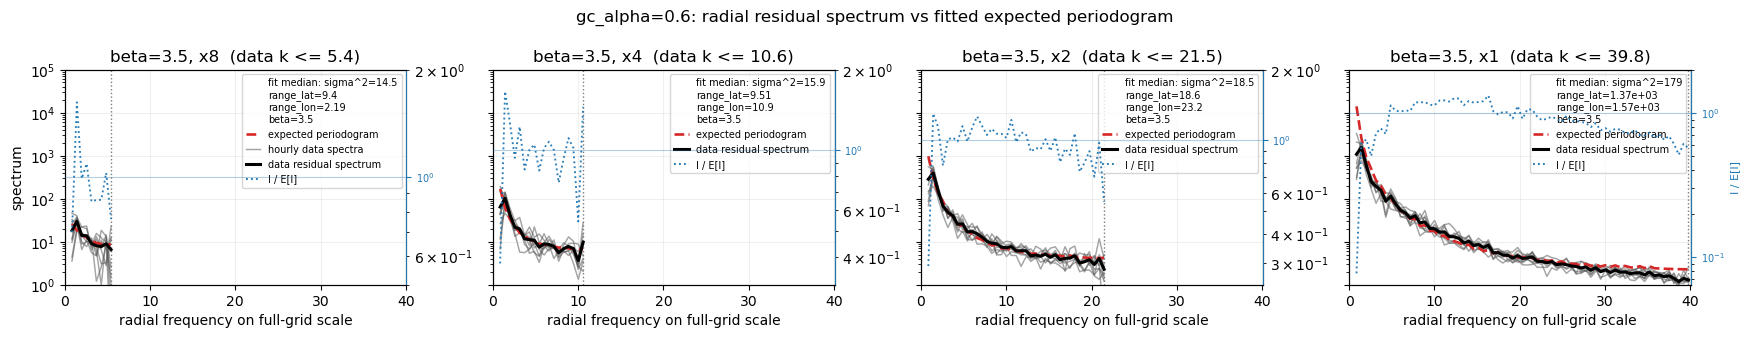

Saved shape diagnostic radial spectrum plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/2x2_real_pure_space_spectral_aniso_cauchy_alpha06_beta3p5_nugget0_clusterb2_121131_060326_shape_diagnostic_median_matched_theory_by_variant_resolution.png


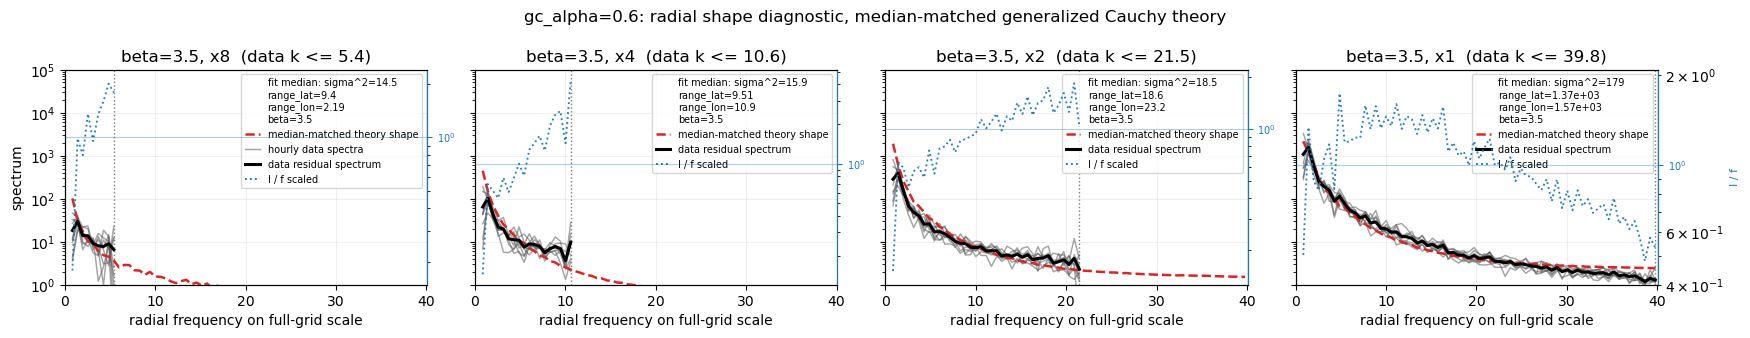

Saved radial expected-vs-rescaled-shape plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/2x2_real_pure_space_spectral_aniso_cauchy_alpha06_beta3p5_nugget0_clusterb2_121131_060326_expected_vs_rescaled_cauchy_shape_by_variant_resolution.png


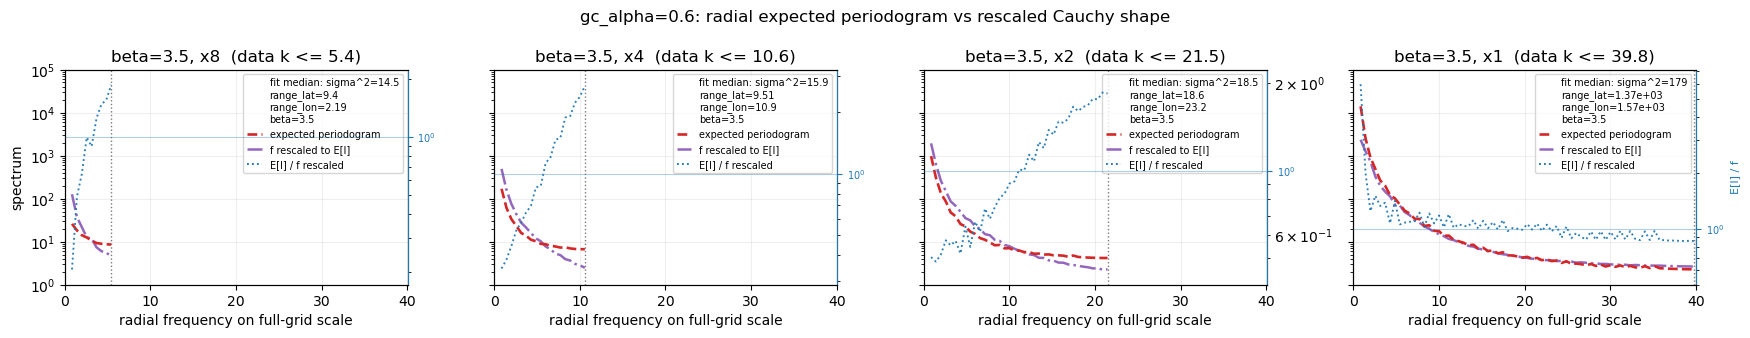

In [12]:

# %%
# Resolution-aware radial spectrum summaries.
# Data spectra are computed on the actual 2D thinned grid for each stride.
# Main theory curves use a DW-style finite-sample expected periodogram:
# fitted covariance + nugget, same mask/FFT normalization, no median scaling.
if 'spectral_df' not in globals():
    spectral_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_radial_spectrum.csv')
required_spectrum_cols = {'theory_spectrum_expected', 'theory_spectrum_scaled'}
missing_spectrum_cols = required_spectrum_cols.difference(spectral_df.columns)
if missing_spectrum_cols:
    raise ValueError(f'spectral_df lacks {sorted(missing_spectrum_cols)}; rerun the RUN_SPECTRUM cell after this update.')

plot_spec = spectral_df.copy()
plot_spec['resolution_label'] = pd.Categorical(
    plot_spec['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)

avg_low_data = (
    plot_spec.dropna(subset=['data_spectrum'])
    .groupby(['variant', 'resolution_label', 'resolution_stride', 'k_bin'], observed=False)
    .agg(
        k_mid=('k_mid', 'mean'),
        data_spectrum=('data_spectrum', 'mean'),
        n_hours=('hour_idx', 'nunique'),
        data_k_max=('data_k_max', 'mean'),
    )
    .reset_index()
)
low_path = OUT_DIR / f'{OUT_PREFIX}_radial_spectrum_lowfreq_only_avg.csv'
avg_low_data.to_csv(low_path, index=False)
print('Saved low-frequency data spectrum:', low_path)

avg_theory_full = (
    plot_spec
    .groupby(['variant', 'resolution_label', 'k_bin'], observed=False)
    .agg(
        k_mid=('k_mid', 'mean'),
        theory_spectrum_expected=('theory_spectrum_expected', 'mean'),
        theory_spectrum_scaled=('theory_spectrum_scaled', 'mean'),
    )
    .reset_index()
)

positive_spectrum_vals = pd.concat(
    [
        pd.to_numeric(avg_low_data['data_spectrum'], errors='coerce'),
        pd.to_numeric(avg_theory_full['theory_spectrum_expected'], errors='coerce'),
    ],
    ignore_index=True,
).replace([np.inf, -np.inf], np.nan).dropna()
positive_spectrum_vals = positive_spectrum_vals[positive_spectrum_vals > 0]
SPECTRUM_YLIM = (1e-1, 1e4) if positive_spectrum_vals.empty else (
    10 ** np.floor(np.log10(float(positive_spectrum_vals.min()))),
    10 ** np.ceil(np.log10(float(positive_spectrum_vals.max()))),
)
print('Radial spectrum y-limits:', SPECTRUM_YLIM)

labels_order = [f'x{s}' for s in RESOLUTION_STRIDES]

def _format_fit_param_label(source_df, variant, resolution_label, direction=None, profile_type=None, prefix='fit median'):
    required = {'variant', 'resolution_label', 'est_sigmasq', 'est_range_lat', 'est_range_lon', 'est_gc_beta'}
    if source_df is None or source_df.empty or not required.issubset(source_df.columns):
        return None
    df = source_df[
        (source_df['variant'].astype(str) == str(variant))
        & (source_df['resolution_label'].astype(str) == str(resolution_label))
    ].copy()
    if direction is not None and 'direction' in df.columns:
        df = df[df['direction'].astype(str) == str(direction)]
    if profile_type is not None and 'profile_type' in df.columns:
        df = df[df['profile_type'].astype(str) == str(profile_type)]
    if df.empty:
        return None
    key_cols = [
        c for c in ['date_str', 'hour_idx', 'time_key', 'variant', 'resolution_label', 'direction', 'profile_type']
        if c in df.columns
    ]
    if key_cols:
        df = df.drop_duplicates(key_cols)
    sigmasq = float(pd.to_numeric(df['est_sigmasq'], errors='coerce').median())
    range_lat = float(pd.to_numeric(df['est_range_lat'], errors='coerce').median())
    range_lon = float(pd.to_numeric(df['est_range_lon'], errors='coerce').median())
    gc_beta = float(pd.to_numeric(df['est_gc_beta'], errors='coerce').median())
    if not np.isfinite(sigmasq) or not np.isfinite(range_lat) or not np.isfinite(range_lon):
        return None
    label = f'{prefix}: sigma^2={sigmasq:.3g}\nrange_lat={range_lat:.3g}\nrange_lon={range_lon:.3g}\nbeta={gc_beta:.3g}'
    return label


def _ratio_from_arrays(x_vals, numerator_vals, denominator_vals):
    ratio_df = pd.DataFrame({
        'k_mid': pd.to_numeric(pd.Series(x_vals), errors='coerce'),
        'numerator': pd.to_numeric(pd.Series(numerator_vals), errors='coerce'),
        'denominator': pd.to_numeric(pd.Series(denominator_vals), errors='coerce'),
    }).replace([np.inf, -np.inf], np.nan)
    good = (
        ratio_df['k_mid'].notna()
        & ratio_df['numerator'].notna()
        & ratio_df['denominator'].notna()
        & (ratio_df['numerator'] > 0)
        & (ratio_df['denominator'] > 0)
    )
    ratio_df = ratio_df.loc[good, ['k_mid']].copy()
    if ratio_df.empty:
        ratio_df['ratio'] = []
        return ratio_df
    ratio_df['ratio'] = (
        pd.to_numeric(pd.Series(numerator_vals), errors='coerce').loc[good].to_numpy(dtype=float)
        / pd.to_numeric(pd.Series(denominator_vals), errors='coerce').loc[good].to_numpy(dtype=float)
    )
    return ratio_df.sort_values('k_mid')


def _ratio_frame(numerator_df, denominator_df, numerator_col, denominator_col, x_col='k_mid'):
    if numerator_df is None or denominator_df is None or numerator_df.empty or denominator_df.empty:
        return pd.DataFrame(columns=[x_col, 'ratio'])
    left = numerator_df[[x_col, numerator_col]].copy()
    right = denominator_df[[x_col, denominator_col]].copy()
    left[x_col] = pd.to_numeric(left[x_col], errors='coerce').round(10)
    right[x_col] = pd.to_numeric(right[x_col], errors='coerce').round(10)
    merged = left.merge(right, on=x_col, how='inner')
    if merged.empty:
        return pd.DataFrame(columns=[x_col, 'ratio'])
    return _ratio_from_arrays(merged[x_col], merged[numerator_col], merged[denominator_col])


def _add_ratio_axis(ax, ratio_df, ylabel=None, color='tab:blue'):
    if ratio_df is None or ratio_df.empty:
        return None
    ratio_df = ratio_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['k_mid', 'ratio'])
    ratio_df = ratio_df[ratio_df['ratio'] > 0].sort_values('k_mid')
    if ratio_df.empty:
        return None
    ratio_ax = ax.twinx()
    ratio_ax.plot(ratio_df['k_mid'], ratio_df['ratio'], color=color, linewidth=1.35, linestyle=':', alpha=0.95, zorder=8)
    ratio_ax.axhline(1.0, color=color, linewidth=0.8, linestyle='-', alpha=0.35, zorder=7)
    ratio_ax.set_yscale('log')
    vals = pd.to_numeric(ratio_df['ratio'], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    vals = vals[vals > 0]
    if not vals.empty:
        lo_raw = float(vals.min())
        hi_raw = float(vals.max())
        lo = max(1e-3, min(0.5, lo_raw / 1.2))
        hi = min(1e3, max(2.0, hi_raw * 1.2))
        if np.isfinite(lo) and np.isfinite(hi) and lo < hi:
            ratio_ax.set_ylim(lo, hi)
    ratio_ax.tick_params(axis='y', colors=color, labelsize=7)
    ratio_ax.spines['right'].set_color(color)
    ratio_ax.grid(False)
    if ylabel:
        ratio_ax.set_ylabel(ylabel, color=color, fontsize=8)
    return ratio_ax


def _expected_rescaled_shape_frame(sub_theory):
    curve = sub_theory[['k_mid', 'theory_spectrum_expected', 'theory_spectrum_scaled']].copy()
    curve = curve.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['k_mid', 'theory_spectrum_expected', 'theory_spectrum_scaled']
    )
    curve = curve[(curve['k_mid'] > 0) & (curve['theory_spectrum_expected'] > 0) & (curve['theory_spectrum_scaled'] > 0)]
    if curve.empty:
        curve['theory_spectrum_shape_rescaled_to_expected'] = []
        return curve
    scale_to_expected = scale_theory_to_data(
        curve['theory_spectrum_expected'], curve['theory_spectrum_scaled'], method='median'
    )
    curve['theory_spectrum_shape_rescaled_to_expected'] = curve['theory_spectrum_scaled'] * scale_to_expected
    return curve

row_specs = [(variant, VARIANT_LABELS.get(variant, variant)) for variant in VARIANTS]
fig, axes = plt.subplots(len(row_specs), len(labels_order), figsize=(4.4 * len(labels_order), 3.4 * len(row_specs)), sharey=True)
if len(row_specs) == 1:
    axes = np.asarray([axes])

for i, (variant, row_title) in enumerate(row_specs):
    for j, label in enumerate(labels_order):
        ax = axes[i, j]
        sub_data = avg_low_data[
            (avg_low_data['variant'] == variant)
            & (avg_low_data['resolution_label'].astype(str) == label)
            & (avg_low_data['k_mid'] > 0)
        ]
        sub_theory = avg_theory_full[
            (avg_theory_full['variant'] == variant)
            & (avg_theory_full['resolution_label'].astype(str) == label)
            & (avg_theory_full['k_mid'] > 0)
        ]
        hour_sub = plot_spec[
            (plot_spec['variant'] == variant)
            & (plot_spec['resolution_label'].astype(str) == label)
            & (plot_spec['k_mid'] > 0)
            & plot_spec['data_spectrum'].notna()
        ]
        if sub_data.empty or sub_theory.empty:
            ax.set_visible(False)
            continue
        k_cut = float(sub_data['data_k_max'].dropna().iloc[0]) if sub_data['data_k_max'].notna().any() else float(sub_data['k_mid'].max())
        param_label = _format_fit_param_label(plot_spec, variant, label)
        if param_label:
            ax.plot([], [], color='none', label=param_label)
        ax.plot(sub_theory['k_mid'], sub_theory['theory_spectrum_expected'], color='tab:red', linewidth=1.9, linestyle='--', label='expected periodogram', zorder=3)
        for h_i, (_, hs) in enumerate(hour_sub.groupby('hour_idx')):
            hour_label = 'hourly data spectra' if (i == 0 and j == 0 and h_i == 0) else None
            ax.plot(hs['k_mid'], hs['data_spectrum'], color='0.35', alpha=0.55, linewidth=1.05, label=hour_label, zorder=1)
        ax.plot(sub_data['k_mid'], sub_data['data_spectrum'], color='black', linewidth=2.2, label='data residual spectrum', zorder=4)
        ratio_df = _ratio_frame(sub_data, sub_theory, 'data_spectrum', 'theory_spectrum_expected')
        _add_ratio_axis(ax, ratio_df, ylabel='I / E[I]' if j == len(labels_order) - 1 else None)
        ax.plot([], [], color='tab:blue', linewidth=1.35, linestyle=':', label='I / E[I]')
        ax.axvline(k_cut, color='0.45', linewidth=1.0, linestyle=':', alpha=0.95, zorder=2)
        ax.set_xlim(0, FULL_K_PLOT_MAX)
        ax.set_ylim(*SPECTRUM_YLIM)
        ax.set_title(f'{row_title}, {label}  (data k <= {k_cut:.1f})')
        ax.set_xlabel('radial frequency on full-grid scale')
        if j == 0:
            ax.set_ylabel('spectrum')
        ax.set_yscale('log')
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, handlelength=1.5)

fig.suptitle(f'gc_alpha={GC_ALPHA}: radial residual spectrum vs fitted expected periodogram')
fig.tight_layout()
combined_spectrum_plot_path = OUT_DIR / f'{OUT_PREFIX}_data_vs_expected_periodogram_by_variant_resolution.png'
fig.savefig(combined_spectrum_plot_path, dpi=180, bbox_inches='tight')
print('Saved radial spectrum plot:', combined_spectrum_plot_path)
plt.show()


# Shape diagnostic: median-matched generalized Cauchy spectral shape.
# This is useful for comparing curvature only; do not read its vertical scale or nugget floor literally.
fig_shape, axes_shape = plt.subplots(len(row_specs), len(labels_order), figsize=(4.4 * len(labels_order), 3.4 * len(row_specs)), sharey=True)
if len(row_specs) == 1:
    axes_shape = np.asarray([axes_shape])

for i, (variant, row_title) in enumerate(row_specs):
    for j, label in enumerate(labels_order):
        ax = axes_shape[i, j]
        sub_data = avg_low_data[
            (avg_low_data['variant'] == variant)
            & (avg_low_data['resolution_label'].astype(str) == label)
            & (avg_low_data['k_mid'] > 0)
        ]
        sub_theory = avg_theory_full[
            (avg_theory_full['variant'] == variant)
            & (avg_theory_full['resolution_label'].astype(str) == label)
            & (avg_theory_full['k_mid'] > 0)
        ]
        hour_sub = plot_spec[
            (plot_spec['variant'] == variant)
            & (plot_spec['resolution_label'].astype(str) == label)
            & (plot_spec['k_mid'] > 0)
            & plot_spec['data_spectrum'].notna()
        ]
        if sub_data.empty or sub_theory.empty:
            ax.set_visible(False)
            continue
        k_cut = float(sub_data['data_k_max'].dropna().iloc[0]) if sub_data['data_k_max'].notna().any() else float(sub_data['k_mid'].max())
        param_label = _format_fit_param_label(plot_spec, variant, label)
        if param_label:
            ax.plot([], [], color='none', label=param_label)
        ax.plot(sub_theory['k_mid'], sub_theory['theory_spectrum_scaled'], color='tab:red', linewidth=1.8, linestyle='--', label='median-matched theory shape', zorder=3)
        for h_i, (_, hs) in enumerate(hour_sub.groupby('hour_idx')):
            hour_label = 'hourly data spectra' if (i == 0 and j == 0 and h_i == 0) else None
            ax.plot(hs['k_mid'], hs['data_spectrum'], color='0.35', alpha=0.55, linewidth=1.05, label=hour_label, zorder=1)
        ax.plot(sub_data['k_mid'], sub_data['data_spectrum'], color='black', linewidth=2.2, label='data residual spectrum', zorder=4)
        ratio_df = _ratio_frame(sub_data, sub_theory, 'data_spectrum', 'theory_spectrum_scaled')
        _add_ratio_axis(ax, ratio_df, ylabel='I / f' if j == len(labels_order) - 1 else None)
        ax.plot([], [], color='tab:blue', linewidth=1.35, linestyle=':', label='I / f scaled')
        ax.axvline(k_cut, color='0.45', linewidth=1.0, linestyle=':', alpha=0.95, zorder=2)
        ax.set_xlim(0, FULL_K_PLOT_MAX)
        ax.set_ylim(*SPECTRUM_YLIM)
        ax.set_title(f'{row_title}, {label}  (data k <= {k_cut:.1f})')
        ax.set_xlabel('radial frequency on full-grid scale')
        if j == 0:
            ax.set_ylabel('spectrum')
        ax.set_yscale('log')
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, handlelength=1.5)

fig_shape.suptitle(f'gc_alpha={GC_ALPHA}: radial shape diagnostic, median-matched generalized Cauchy theory')
fig_shape.tight_layout()
shape_diagnostic_plot_path = OUT_DIR / f'{OUT_PREFIX}_shape_diagnostic_median_matched_theory_by_variant_resolution.png'
fig_shape.savefig(shape_diagnostic_plot_path, dpi=180, bbox_inches='tight')
print('Saved shape diagnostic radial spectrum plot:', shape_diagnostic_plot_path)
plt.show()


# Expected-periodogram vs continuous Cauchy shape after rescaling f to E[I].
# This isolates finite-grid mask/window and leakage effects from the model shape.
fig_ei_shape, axes_ei_shape = plt.subplots(len(row_specs), len(labels_order), figsize=(4.4 * len(labels_order), 3.4 * len(row_specs)), sharey=True)
if len(row_specs) == 1:
    axes_ei_shape = np.asarray([axes_ei_shape])

for i, (variant, row_title) in enumerate(row_specs):
    for j, label in enumerate(labels_order):
        ax = axes_ei_shape[i, j]
        sub_data = avg_low_data[
            (avg_low_data['variant'] == variant)
            & (avg_low_data['resolution_label'].astype(str) == label)
            & (avg_low_data['k_mid'] > 0)
        ]
        sub_theory = avg_theory_full[
            (avg_theory_full['variant'] == variant)
            & (avg_theory_full['resolution_label'].astype(str) == label)
            & (avg_theory_full['k_mid'] > 0)
        ]
        curve = _expected_rescaled_shape_frame(sub_theory)
        if curve.empty:
            ax.set_visible(False)
            continue
        k_cut = np.nan
        if not sub_data.empty:
            k_cut = float(sub_data['data_k_max'].dropna().iloc[0]) if sub_data['data_k_max'].notna().any() else float(sub_data['k_mid'].max())
        param_label = _format_fit_param_label(plot_spec, variant, label)
        if param_label:
            ax.plot([], [], color='none', label=param_label)
        ax.plot(curve['k_mid'], curve['theory_spectrum_expected'], color='tab:red', linewidth=1.9, linestyle='--', label='expected periodogram', zorder=4)
        ax.plot(curve['k_mid'], curve['theory_spectrum_shape_rescaled_to_expected'], color='tab:purple', linewidth=1.8, linestyle='-.', label='f rescaled to E[I]', zorder=3)
        ratio_df = _ratio_from_arrays(curve['k_mid'], curve['theory_spectrum_expected'], curve['theory_spectrum_shape_rescaled_to_expected'])
        _add_ratio_axis(ax, ratio_df, ylabel='E[I] / f' if j == len(labels_order) - 1 else None)
        ax.plot([], [], color='tab:blue', linewidth=1.35, linestyle=':', label='E[I] / f rescaled')
        if np.isfinite(k_cut):
            ax.axvline(k_cut, color='0.45', linewidth=1.0, linestyle=':', alpha=0.95, zorder=2)
        ax.set_xlim(0, FULL_K_PLOT_MAX)
        ax.set_ylim(*SPECTRUM_YLIM)
        title_suffix = f'  (data k <= {k_cut:.1f})' if np.isfinite(k_cut) else ''
        ax.set_title(f'{row_title}, {label}{title_suffix}')
        ax.set_xlabel('radial frequency on full-grid scale')
        if j == 0:
            ax.set_ylabel('spectrum')
        ax.set_yscale('log')
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, handlelength=1.5)

fig_ei_shape.suptitle(f'gc_alpha={GC_ALPHA}: radial expected periodogram vs rescaled Cauchy shape')
fig_ei_shape.tight_layout()
ei_shape_plot_path = OUT_DIR / f'{OUT_PREFIX}_expected_vs_rescaled_cauchy_shape_by_variant_resolution.png'
fig_ei_shape.savefig(ei_shape_plot_path, dpi=180, bbox_inches='tight')
print('Saved radial expected-vs-rescaled-shape plot:', ei_shape_plot_path)
plt.show()



Directional expected-periodogram y-limits: (0.1, 1000.0)


Saved directional expected-periodogram plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/2x2_real_pure_space_spectral_aniso_cauchy_alpha06_beta3p5_nugget0_clusterb2_121131_060326_directional_data_vs_expected_periodogram_by_variant_resolution.png


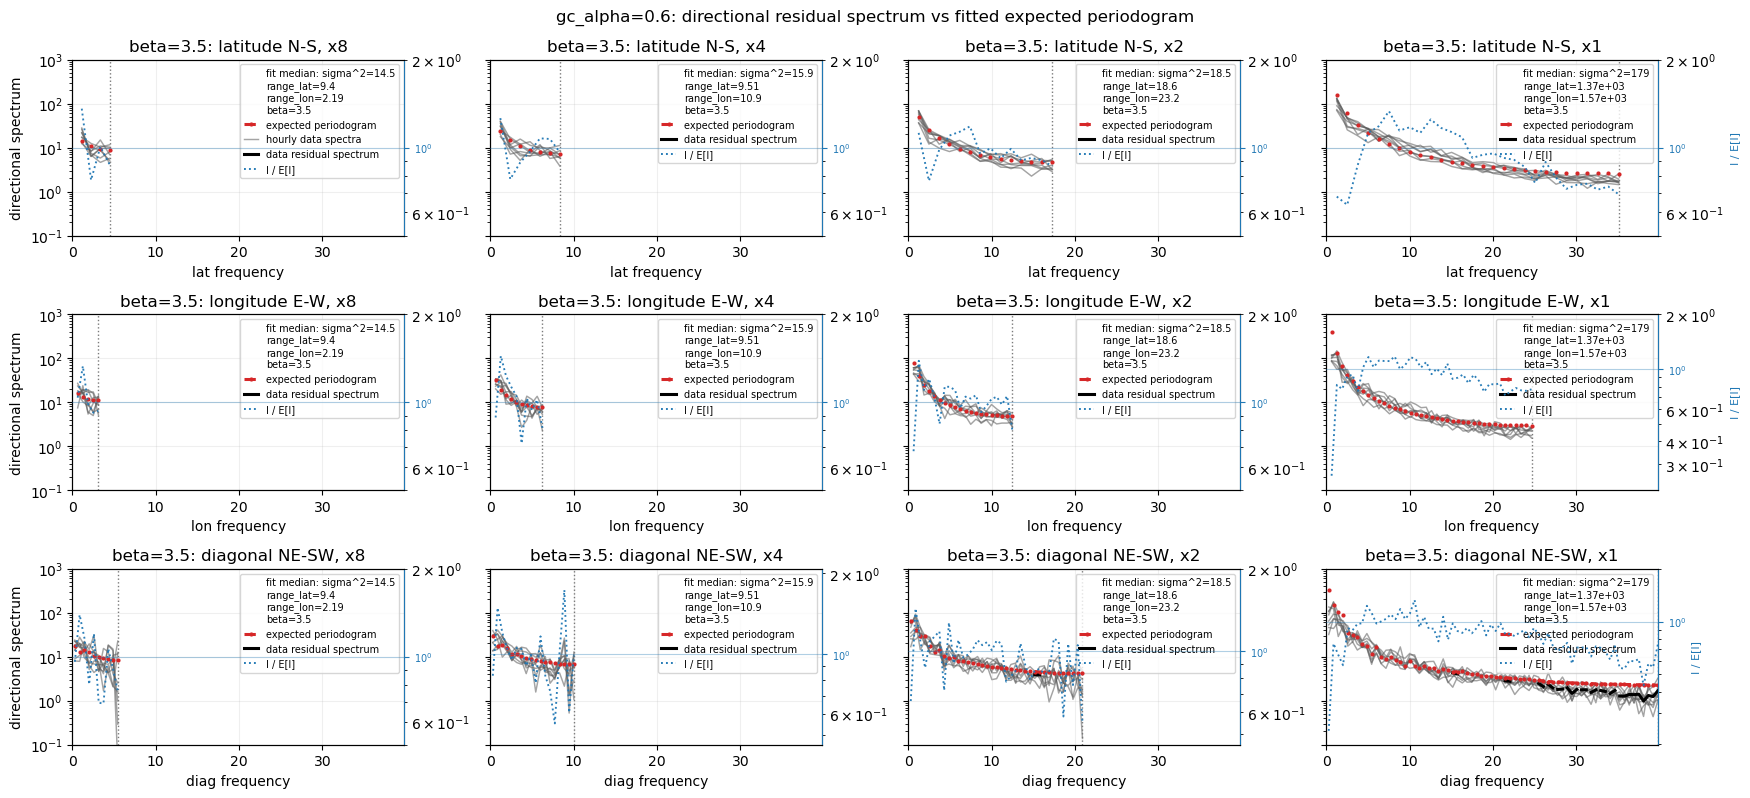

Directional scaled-shape y-limits: (0.1, 1000.0)


Saved directional scaled-shape plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/2x2_real_pure_space_spectral_aniso_cauchy_alpha06_beta3p5_nugget0_clusterb2_121131_060326_shape_diagnostic_directional_scaled_cauchy_by_variant_resolution.png


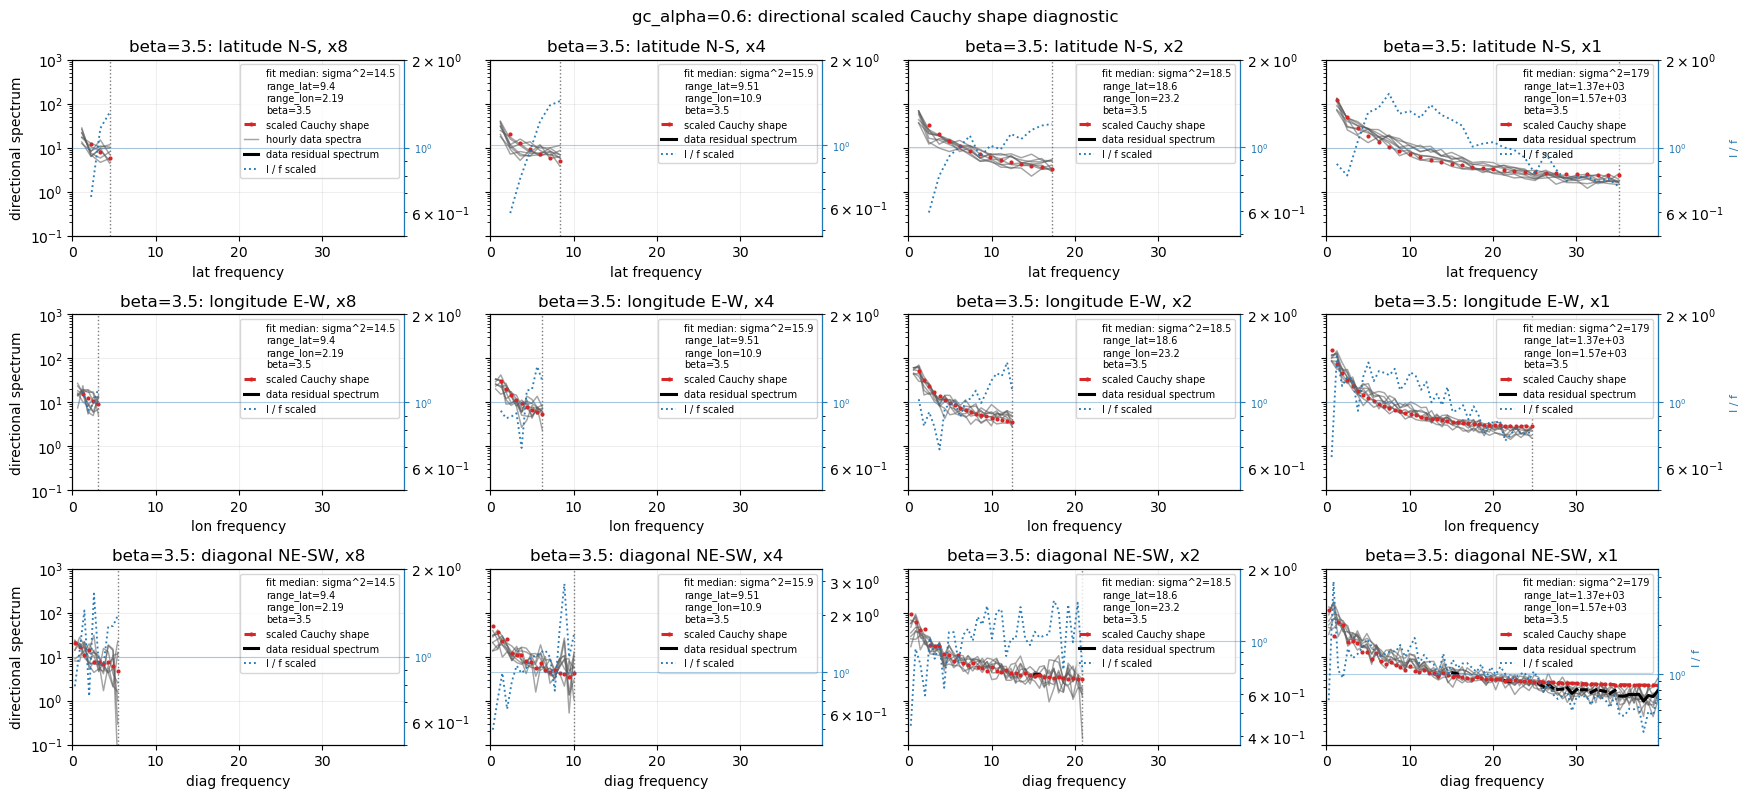

Saved directional expected-vs-rescaled-shape plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/2x2_real_pure_space_spectral_aniso_cauchy_alpha06_beta3p5_nugget0_clusterb2_121131_060326_directional_expected_vs_rescaled_cauchy_shape_by_variant_resolution.png


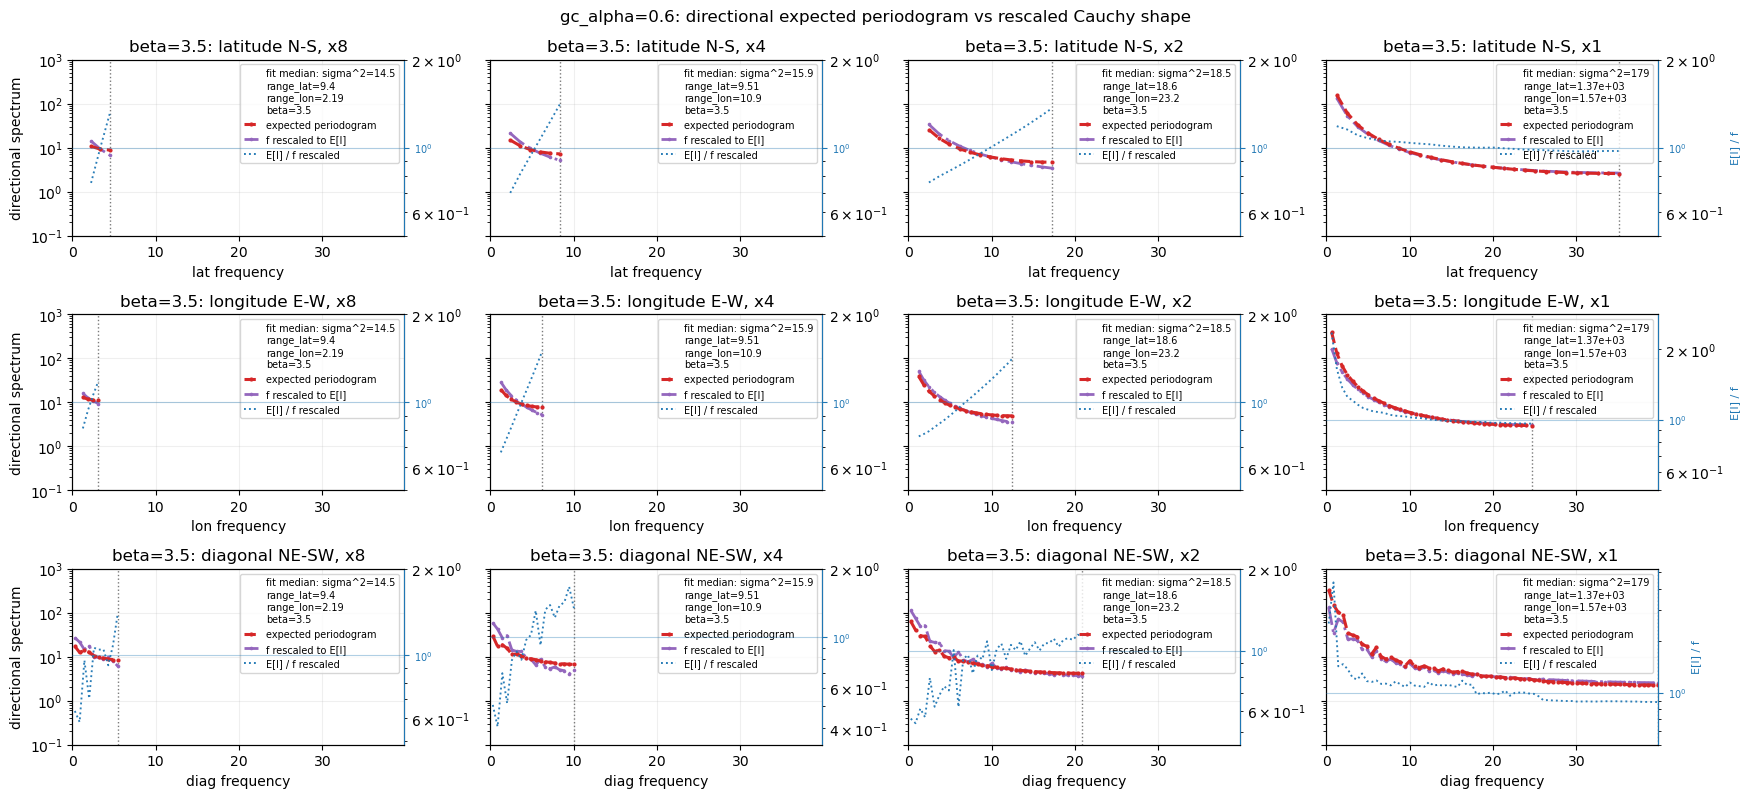

In [13]:

# %%
# Directional lat/lon/diagonal spectrum diagnostics.
# These are directional summaries of the same 2D masked/projected FFT
# periodogram used by the radial diagnostic, so empirical and expected curves
# share the same finite-grid convention.
if 'directional_spectral_df' not in globals():
    directional_spectral_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_directional_spectrum_lat_lon_diag.csv')
required_dir_cols = {'theory_spectrum_expected', 'theory_spectrum_scaled', 'directional_bin_mode'}
missing_dir_cols = required_dir_cols.difference(directional_spectral_df.columns)
if missing_dir_cols:
    raise ValueError(f'directional_spectral_df lacks {sorted(missing_dir_cols)}; rerun the RUN_SPECTRUM cell after this update.')

plot_dir = directional_spectral_df.copy()
plot_dir['resolution_label'] = pd.Categorical(
    plot_dir['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)
missing_directions = set(DIRECTIONS).difference(set(plot_dir['direction'].astype(str).unique()))
if missing_directions:
    raise ValueError(f'directional_spectral_df lacks directions {sorted(missing_directions)}; rerun the RUN_SPECTRUM cell.')

avg_dir_data = (
    plot_dir.dropna(subset=['data_spectrum'])
    .groupby(['variant', 'direction', 'resolution_label', 'resolution_stride', 'k_mid'], observed=False)
    .agg(
        data_spectrum=('data_spectrum', 'mean'),
        n_hours=('hour_idx', 'nunique'),
        data_k_max=('data_k_max', 'mean'),
    )
    .reset_index()
)
avg_dir_theory = (
    plot_dir
    .groupby(['variant', 'direction', 'resolution_label', 'k_mid'], observed=False)
    .agg(
        theory_spectrum_expected=('theory_spectrum_expected', 'mean'),
        theory_spectrum_scaled=('theory_spectrum_scaled', 'mean'),
    )
    .reset_index()
)

dir_expected_vals = pd.concat(
    [
        pd.to_numeric(avg_dir_data['data_spectrum'], errors='coerce'),
        pd.to_numeric(avg_dir_theory['theory_spectrum_expected'], errors='coerce'),
    ],
    ignore_index=True,
).replace([np.inf, -np.inf], np.nan).dropna()
dir_expected_vals = dir_expected_vals[dir_expected_vals > 0]
DIR_EXPECTED_SPECTRUM_YLIM = SPECTRUM_YLIM if dir_expected_vals.empty else (
    10 ** np.floor(np.log10(float(dir_expected_vals.min()))),
    10 ** np.ceil(np.log10(float(dir_expected_vals.max()))),
)
print('Directional expected-periodogram y-limits:', DIR_EXPECTED_SPECTRUM_YLIM)

variant_direction_labels = [(variant, VARIANT_LABELS.get(variant, variant)) for variant in VARIANTS]
row_specs = [
    (variant, direction, f'{variant_label}: {DIRECTION_LABELS[direction]}')
    for variant, variant_label in variant_direction_labels
    for direction in DIRECTIONS
]
labels_order = [f'x{s}' for s in RESOLUTION_STRIDES]
fig, axes = plt.subplots(len(row_specs), len(labels_order), figsize=(4.4 * len(labels_order), 2.7 * len(row_specs)), sharey=True)

for i, (variant, direction, row_title) in enumerate(row_specs):
    for j, label in enumerate(labels_order):
        ax = axes[i, j]
        sub_data = avg_dir_data[
            (avg_dir_data['variant'] == variant)
            & (avg_dir_data['direction'] == direction)
            & (avg_dir_data['resolution_label'].astype(str) == label)
            & (avg_dir_data['k_mid'] > 0)
        ]
        sub_theory = avg_dir_theory[
            (avg_dir_theory['variant'] == variant)
            & (avg_dir_theory['direction'] == direction)
            & (avg_dir_theory['resolution_label'].astype(str) == label)
            & (avg_dir_theory['k_mid'] > 0)
        ]
        hour_sub = plot_dir[
            (plot_dir['variant'] == variant)
            & (plot_dir['direction'] == direction)
            & (plot_dir['resolution_label'].astype(str) == label)
            & (plot_dir['k_mid'] > 0)
            & plot_dir['data_spectrum'].notna()
        ]
        if sub_data.empty or sub_theory.empty:
            ax.set_visible(False)
            continue
        k_cut = float(sub_data['data_k_max'].dropna().iloc[0]) if sub_data['data_k_max'].notna().any() else float(sub_data['k_mid'].max())
        param_label = _format_fit_param_label(plot_spec, variant, label)
        if param_label:
            ax.plot([], [], color='none', label=param_label)
        ax.plot(sub_theory['k_mid'], sub_theory['theory_spectrum_expected'], color='tab:red', linewidth=2.2, linestyle='--', marker='o', markersize=3.0, markerfacecolor='tab:red', markeredgewidth=0.0, label='expected periodogram', zorder=6)
        for h_i, (_, hs) in enumerate(hour_sub.groupby('hour_idx')):
            hour_label = 'hourly data spectra' if (i == 0 and j == 0 and h_i == 0) else None
            ax.plot(hs['k_mid'], hs['data_spectrum'], color='0.35', alpha=0.55, linewidth=1.05, label=hour_label, zorder=1)
        ax.plot(sub_data['k_mid'], sub_data['data_spectrum'], color='black', linewidth=2.2, label='data residual spectrum', zorder=4)
        ratio_df = _ratio_frame(sub_data, sub_theory, 'data_spectrum', 'theory_spectrum_expected')
        _add_ratio_axis(ax, ratio_df, ylabel='I / E[I]' if j == len(labels_order) - 1 else None)
        ax.plot([], [], color='tab:blue', linewidth=1.35, linestyle=':', label='I / E[I]')
        ax.axvline(k_cut, color='0.45', linewidth=1.0, linestyle=':', alpha=0.95, zorder=2)
        ax.set_xlim(0, max(float(sub_theory['k_mid'].max()), float(sub_data['k_mid'].max())))
        ax.set_ylim(*DIR_EXPECTED_SPECTRUM_YLIM)
        ax.set_title(f'{row_title}, {label}')
        ax.set_xlabel(f'{direction} frequency')
        if j == 0:
            ax.set_ylabel('directional spectrum')
        ax.set_yscale('log')
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, handlelength=1.5)

fig.suptitle(f'gc_alpha={GC_ALPHA}: directional residual spectrum vs fitted expected periodogram')
fig.tight_layout()
directional_expected_plot_path = OUT_DIR / f'{OUT_PREFIX}_directional_data_vs_expected_periodogram_by_variant_resolution.png'
fig.savefig(directional_expected_plot_path, dpi=180, bbox_inches='tight')
print('Saved directional expected-periodogram plot:', directional_expected_plot_path)
plt.show()


dir_shape_vals = pd.concat(
    [
        pd.to_numeric(avg_dir_data['data_spectrum'], errors='coerce'),
        pd.to_numeric(avg_dir_theory['theory_spectrum_scaled'], errors='coerce'),
    ],
    ignore_index=True,
).replace([np.inf, -np.inf], np.nan).dropna()
dir_shape_vals = dir_shape_vals[dir_shape_vals > 0]
DIR_SHAPE_SPECTRUM_YLIM = SPECTRUM_YLIM if dir_shape_vals.empty else (
    10 ** np.floor(np.log10(float(dir_shape_vals.min()))),
    10 ** np.ceil(np.log10(float(dir_shape_vals.max()))),
)
print('Directional scaled-shape y-limits:', DIR_SHAPE_SPECTRUM_YLIM)

fig_shape, axes_shape = plt.subplots(len(row_specs), len(labels_order), figsize=(4.4 * len(labels_order), 2.7 * len(row_specs)), sharey=True)
for i, (variant, direction, row_title) in enumerate(row_specs):
    for j, label in enumerate(labels_order):
        ax = axes_shape[i, j]
        sub_data = avg_dir_data[
            (avg_dir_data['variant'] == variant)
            & (avg_dir_data['direction'] == direction)
            & (avg_dir_data['resolution_label'].astype(str) == label)
            & (avg_dir_data['k_mid'] > 0)
        ]
        sub_theory = avg_dir_theory[
            (avg_dir_theory['variant'] == variant)
            & (avg_dir_theory['direction'] == direction)
            & (avg_dir_theory['resolution_label'].astype(str) == label)
            & (avg_dir_theory['k_mid'] > 0)
        ]
        hour_sub = plot_dir[
            (plot_dir['variant'] == variant)
            & (plot_dir['direction'] == direction)
            & (plot_dir['resolution_label'].astype(str) == label)
            & (plot_dir['k_mid'] > 0)
            & plot_dir['data_spectrum'].notna()
        ]
        if sub_data.empty or sub_theory.empty:
            ax.set_visible(False)
            continue
        k_cut = float(sub_data['data_k_max'].dropna().iloc[0]) if sub_data['data_k_max'].notna().any() else float(sub_data['k_mid'].max())
        param_label = _format_fit_param_label(plot_spec, variant, label)
        if param_label:
            ax.plot([], [], color='none', label=param_label)
        ax.plot(sub_theory['k_mid'], sub_theory['theory_spectrum_scaled'], color='tab:red', linewidth=2.2, linestyle='--', marker='o', markersize=3.0, markerfacecolor='tab:red', markeredgewidth=0.0, label='scaled Cauchy shape', zorder=6)
        for h_i, (_, hs) in enumerate(hour_sub.groupby('hour_idx')):
            hour_label = 'hourly data spectra' if (i == 0 and j == 0 and h_i == 0) else None
            ax.plot(hs['k_mid'], hs['data_spectrum'], color='0.35', alpha=0.55, linewidth=1.05, label=hour_label, zorder=1)
        ax.plot(sub_data['k_mid'], sub_data['data_spectrum'], color='black', linewidth=2.2, label='data residual spectrum', zorder=4)
        ratio_df = _ratio_frame(sub_data, sub_theory, 'data_spectrum', 'theory_spectrum_scaled')
        _add_ratio_axis(ax, ratio_df, ylabel='I / f' if j == len(labels_order) - 1 else None)
        ax.plot([], [], color='tab:blue', linewidth=1.35, linestyle=':', label='I / f scaled')
        ax.axvline(k_cut, color='0.45', linewidth=1.0, linestyle=':', alpha=0.95, zorder=2)
        ax.set_xlim(0, max(float(sub_theory['k_mid'].max()), float(sub_data['k_mid'].max())))
        ax.set_ylim(*DIR_SHAPE_SPECTRUM_YLIM)
        ax.set_title(f'{row_title}, {label}')
        ax.set_xlabel(f'{direction} frequency')
        if j == 0:
            ax.set_ylabel('directional spectrum')
        ax.set_yscale('log')
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, handlelength=1.5)

fig_shape.suptitle(f'gc_alpha={GC_ALPHA}: directional scaled Cauchy shape diagnostic')
fig_shape.tight_layout()
directional_shape_plot_path = OUT_DIR / f'{OUT_PREFIX}_shape_diagnostic_directional_scaled_cauchy_by_variant_resolution.png'
fig_shape.savefig(directional_shape_plot_path, dpi=180, bbox_inches='tight')
print('Saved directional scaled-shape plot:', directional_shape_plot_path)
plt.show()


# Directional expected-periodogram vs continuous Cauchy shape after rescaling f to E[I].
fig_ei_dir_shape, axes_ei_dir_shape = plt.subplots(len(row_specs), len(labels_order), figsize=(4.4 * len(labels_order), 2.7 * len(row_specs)), sharey=True)
for i, (variant, direction, row_title) in enumerate(row_specs):
    for j, label in enumerate(labels_order):
        ax = axes_ei_dir_shape[i, j]
        sub_data = avg_dir_data[
            (avg_dir_data['variant'] == variant)
            & (avg_dir_data['direction'] == direction)
            & (avg_dir_data['resolution_label'].astype(str) == label)
            & (avg_dir_data['k_mid'] > 0)
        ]
        sub_theory = avg_dir_theory[
            (avg_dir_theory['variant'] == variant)
            & (avg_dir_theory['direction'] == direction)
            & (avg_dir_theory['resolution_label'].astype(str) == label)
            & (avg_dir_theory['k_mid'] > 0)
        ]
        curve = _expected_rescaled_shape_frame(sub_theory)
        if curve.empty:
            ax.set_visible(False)
            continue
        k_cut = np.nan
        if not sub_data.empty:
            k_cut = float(sub_data['data_k_max'].dropna().iloc[0]) if sub_data['data_k_max'].notna().any() else float(sub_data['k_mid'].max())
        param_label = _format_fit_param_label(plot_spec, variant, label)
        if param_label:
            ax.plot([], [], color='none', label=param_label)
        ax.plot(curve['k_mid'], curve['theory_spectrum_expected'], color='tab:red', linewidth=2.2, linestyle='--', marker='o', markersize=3.0, markerfacecolor='tab:red', markeredgewidth=0.0, label='expected periodogram', zorder=6)
        ax.plot(curve['k_mid'], curve['theory_spectrum_shape_rescaled_to_expected'], color='tab:purple', linewidth=2.0, linestyle='-.', marker='o', markersize=2.6, markerfacecolor='tab:purple', markeredgewidth=0.0, label='f rescaled to E[I]', zorder=5)
        ratio_df = _ratio_from_arrays(curve['k_mid'], curve['theory_spectrum_expected'], curve['theory_spectrum_shape_rescaled_to_expected'])
        _add_ratio_axis(ax, ratio_df, ylabel='E[I] / f' if j == len(labels_order) - 1 else None)
        ax.plot([], [], color='tab:blue', linewidth=1.35, linestyle=':', label='E[I] / f rescaled')
        if np.isfinite(k_cut):
            ax.axvline(k_cut, color='0.45', linewidth=1.0, linestyle=':', alpha=0.95, zorder=2)
        x_max = float(curve['k_mid'].max())
        if not sub_data.empty:
            x_max = max(x_max, float(sub_data['k_mid'].max()))
        ax.set_xlim(0, x_max)
        ax.set_ylim(*DIR_EXPECTED_SPECTRUM_YLIM)
        ax.set_title(f'{row_title}, {label}')
        ax.set_xlabel(f'{direction} frequency')
        if j == 0:
            ax.set_ylabel('directional spectrum')
        ax.set_yscale('log')
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, handlelength=1.5)

fig_ei_dir_shape.suptitle(f'gc_alpha={GC_ALPHA}: directional expected periodogram vs rescaled Cauchy shape')
fig_ei_dir_shape.tight_layout()
directional_ei_shape_plot_path = OUT_DIR / f'{OUT_PREFIX}_directional_expected_vs_rescaled_cauchy_shape_by_variant_resolution.png'
fig_ei_dir_shape.savefig(directional_ei_shape_plot_path, dpi=180, bbox_inches='tight')
print('Saved directional expected-vs-rescaled-shape plot:', directional_ei_shape_plot_path)
plt.show()


In [14]:
# Partial-profile spectral diagnostics are skipped in this Cauchy notebook.
print('No partial-profile spectra: profile fits are disabled for anisotropic generalized Cauchy.')


No partial-profile spectra: profile fits are disabled for anisotropic generalized Cauchy.
